# ACP + K-means — student_mat

ACP sur les 16 variables quantitatives, conservation des 9 premières composantes (>80% de variance), puis K-means avec k=3, 4 et 5.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


## 1. Chargement et préparation

In [8]:
student_mat = pd.read_csv("../donnees/student-mat.csv")

# Variables quantitatives uniquement
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3']

df_num = student_mat[num_cols].dropna()
print(f"Dimensions : {df_num.shape}  ({df_num.shape[0]} individus, {df_num.shape[1]} variables)")

# Centrage-réduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


Dimensions : (395, 16)  (395 individus, 16 variables)


## 2. ACP — Éboulis et variance expliquée

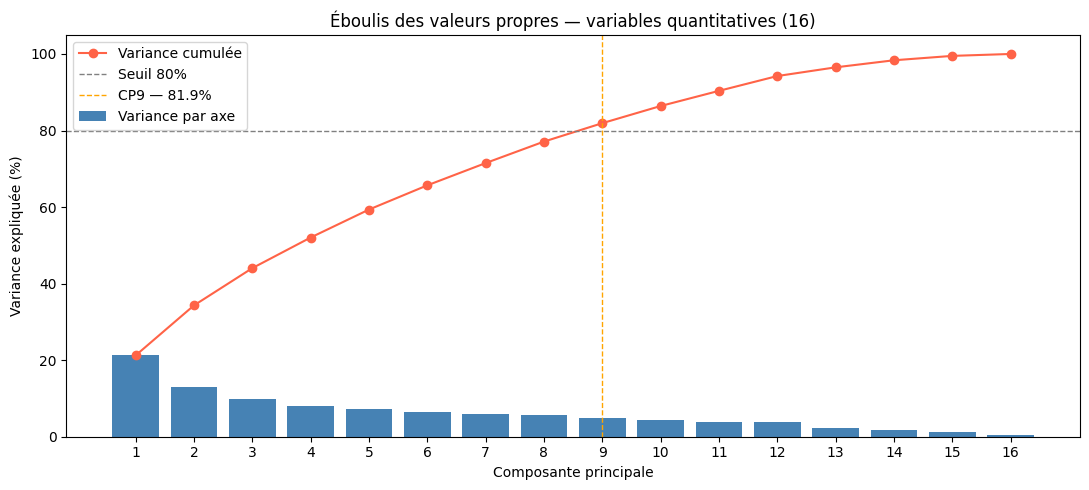

Variance par composante :
  CP 1 :  21.2%   cumulé :  21.2%
  CP 2 :  13.1%   cumulé :  34.3%
  CP 3 :   9.7%   cumulé :  44.0%
  CP 4 :   8.0%   cumulé :  52.0%
  CP 5 :   7.3%   cumulé :  59.3%
  CP 6 :   6.3%   cumulé :  65.7%
  CP 7 :   5.8%   cumulé :  71.5%
  CP 8 :   5.6%   cumulé :  77.1%
  CP 9 :   4.8%   cumulé :  81.9% ← seuil 80%
  CP10 :   4.5%   cumulé :  86.4%
  CP11 :   4.0%   cumulé :  90.4%
  CP12 :   3.9%   cumulé :  94.2%
  CP13 :   2.3%   cumulé :  96.5%
  CP14 :   1.8%   cumulé :  98.4%
  CP15 :   1.1%   cumulé :  99.5%
  CP16 :   0.5%   cumulé : 100.0%


In [9]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)
n_comp      = len(explained)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(1, n_comp+1), explained * 100, color='steelblue', label='Variance par axe')
ax.plot(range(1, n_comp+1), cumulative * 100, 'o-', color='tomato', label='Variance cumulée')
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='Seuil 80%')
ax.axvline(9, color='orange', linestyle='--', linewidth=1, label='CP9 — 81.9%')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax.set_title('Éboulis des valeurs propres — variables quantitatives (16)')
ax.set_xticks(range(1, n_comp+1))
ax.legend()
plt.tight_layout()
plt.show()

print("Variance par composante :")
for i, (v, c) in enumerate(zip(explained, cumulative)):
    marker = " ← seuil 80%" if i == 8 else ""
    print(f"  CP{i+1:2d} : {v*100:5.1f}%   cumulé : {c*100:5.1f}%{marker}")


## 3. Cercle des corrélations (CP1 / CP2)

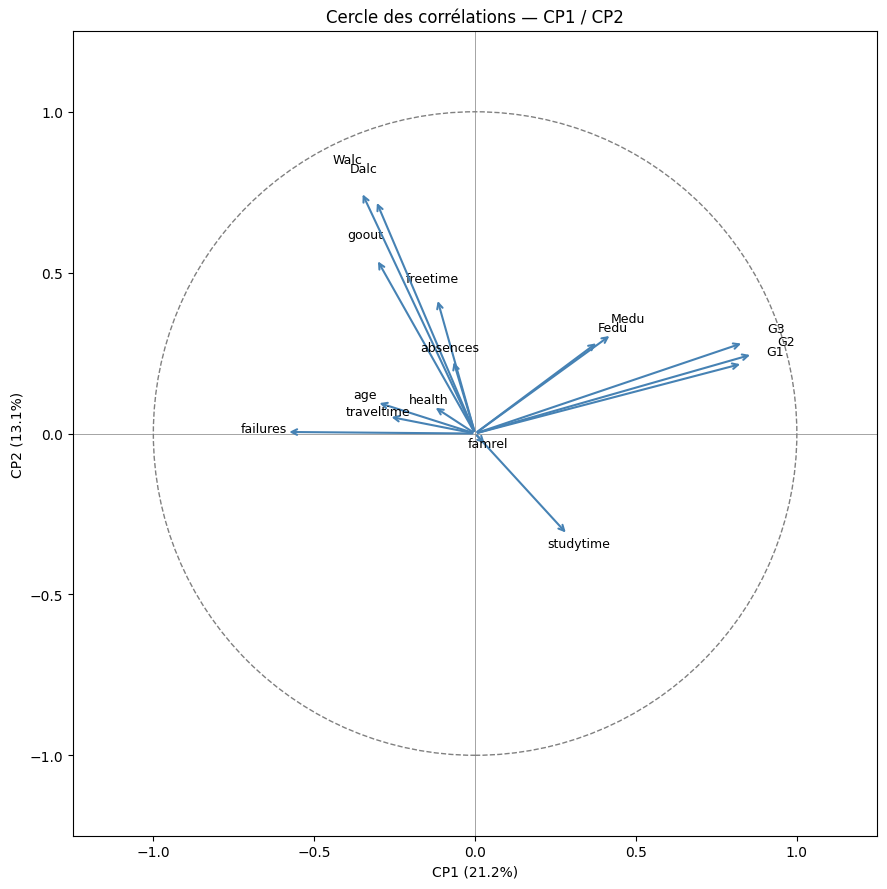

In [10]:
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

# Coordonnées des variables dans le cercle
coords = pca_2.components_.T * np.sqrt(pca_2.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))
for i, var in enumerate(num_cols):
    ax.annotate("", xy=(coords[i, 0], coords[i, 1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5))
    ax.text(coords[i, 0] * 1.12, coords[i, 1] * 1.12, var, fontsize=9, ha='center')

cercle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cercle des corrélations — CP1 / CP2')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## 4. Réduction à 9 composantes (81.9% de variance)

On conserve les 9 premières composantes principales qui capturent **81.9%** de la variance totale (seuil 80%).

In [11]:
N_COMP = 9
pca9 = PCA(n_components=N_COMP, random_state=42)
X_pca9 = pca9.fit_transform(X_scaled)

print(f"Variance expliquée par les {N_COMP} composantes : {pca9.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Dimensions de l'espace réduit : {X_pca9.shape}")


Variance expliquée par les 9 composantes : 81.9%
Dimensions de l'espace réduit : (395, 9)


## 5. Méthode du coude — choix de k

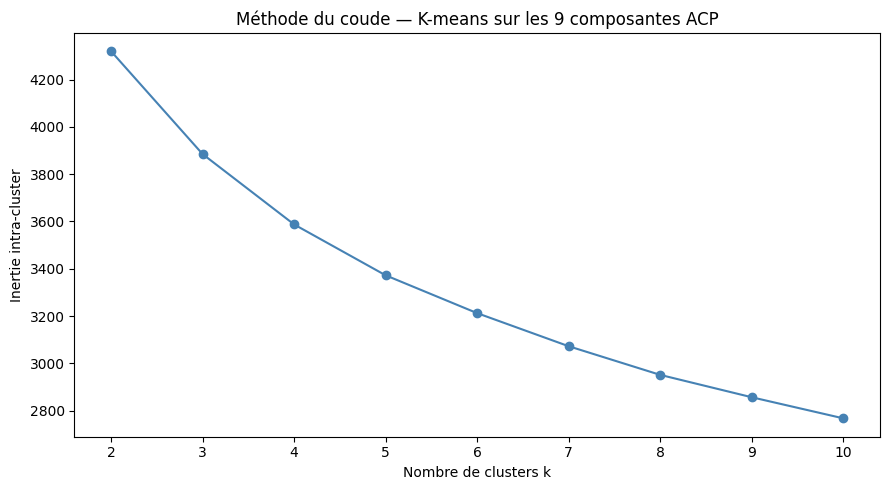

In [12]:
n_clusters_list = range(2, 11)
inertias = []

for k in n_clusters_list:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_pca9)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(n_clusters_list), inertias, 'o-', color='steelblue')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude — K-means sur les 9 composantes ACP')
plt.xticks(list(n_clusters_list))
plt.tight_layout()
plt.show()


## 6. K-means — k=3, k=4, k=5

In [13]:
def plot_kmeans(X_pca9, X_pca2, k, df_num, num_cols):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca9)

    palette = ['steelblue', 'orange', 'tomato', 'mediumseagreen', 'purple']
    colors  = [palette[c] for c in labels]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Scatter ACP
    for c in range(k):
        mask = labels == c
        axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                        c=palette[c], label=f'Cluster {c} (n={mask.sum()})',
                        alpha=0.6, s=35, edgecolors='none')
    axes[0].set_xlabel(f'CP1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'CP2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title(f'K-means k={k} — Projection CP1/CP2')
    axes[0].legend(fontsize=9)

    # Profil moyen (heatmap)
    df_tmp = df_num.copy()
    df_tmp['cluster'] = labels
    profile = df_tmp.groupby('cluster')[num_cols].mean()
    profile_norm = (profile - profile.mean()) / profile.std()

    im = axes[1].imshow(profile_norm.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    axes[1].set_xticks(range(len(num_cols))); axes[1].set_xticklabels(num_cols, rotation=35, ha='right')
    axes[1].set_yticks(range(k)); axes[1].set_yticklabels([f'Cluster {i}' for i in range(k)])
    axes[1].set_title(f'Profil moyen des clusters (normalisé) — k={k}')
    plt.colorbar(im, ax=axes[1], label='Écarts à la moyenne')
    for i in range(k):
        for j in range(len(num_cols)):
            axes[1].text(j, i, f'{profile.values[i,j]:.1f}', ha='center', va='center', fontsize=7)

    plt.suptitle(f'K-means — k={k} clusters', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"Taille des clusters (k={k}) :")
    nb_indi_tot = 649
    for c in range(k):
        nb_indi_cluster = (labels==c).sum()
        print(f"  Cluster {c} : {(labels==c).sum()} individus {(nb_indi_cluster/nb_indi_tot)*100:.2f}%")
    print()
    return labels


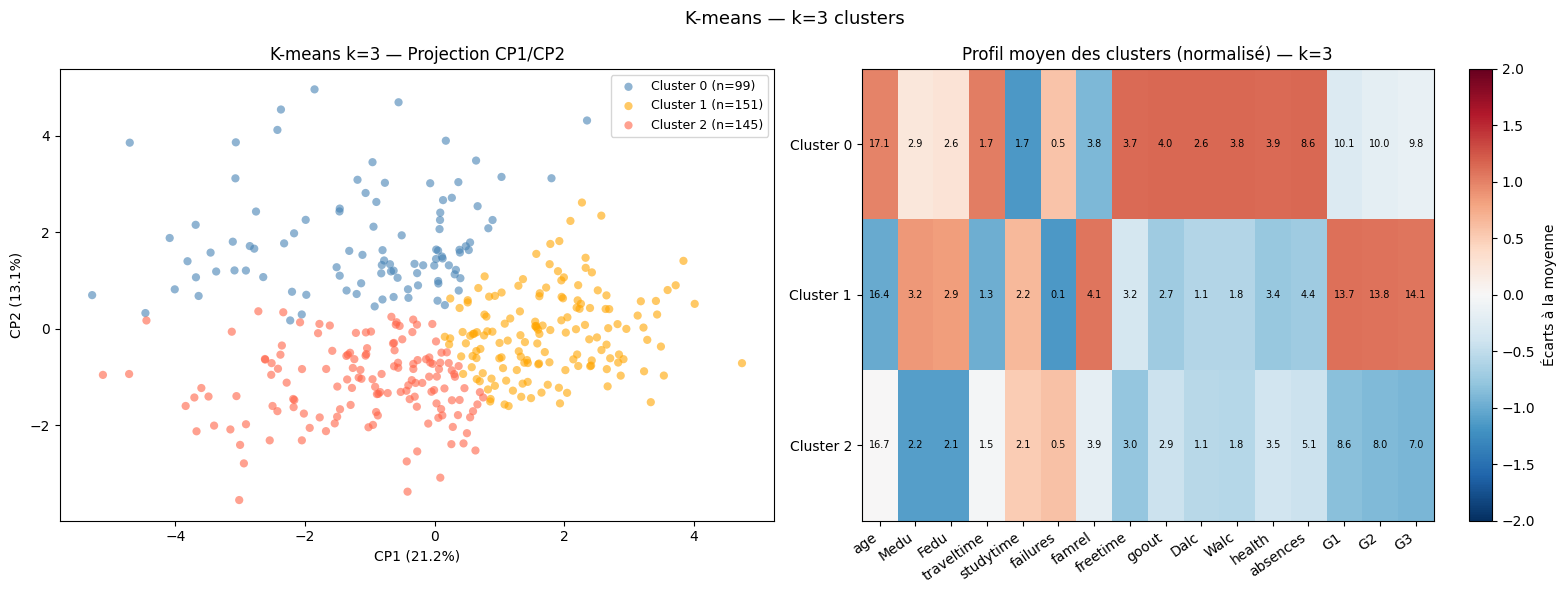

Taille des clusters (k=3) :
  Cluster 0 : 99 individus 15.25%
  Cluster 1 : 151 individus 23.27%
  Cluster 2 : 145 individus 22.34%



In [14]:
labels3 = plot_kmeans(X_pca9, X_pca2, 3, df_num, num_cols)

### k=3 — 3 profils lisibles dans la heatmap :

- Cluster 0 (99) : âge élevé, peu d'alcool, notes moyennes

- Cluster 1 (151) : profil "moyen" — toutes les valeurs proches de la moyenne
- Cluster 2 (145) : Medu/Fedu élevés, bonnes notes G1/G2/G3, peu d'alcool → élèves bien encadrés

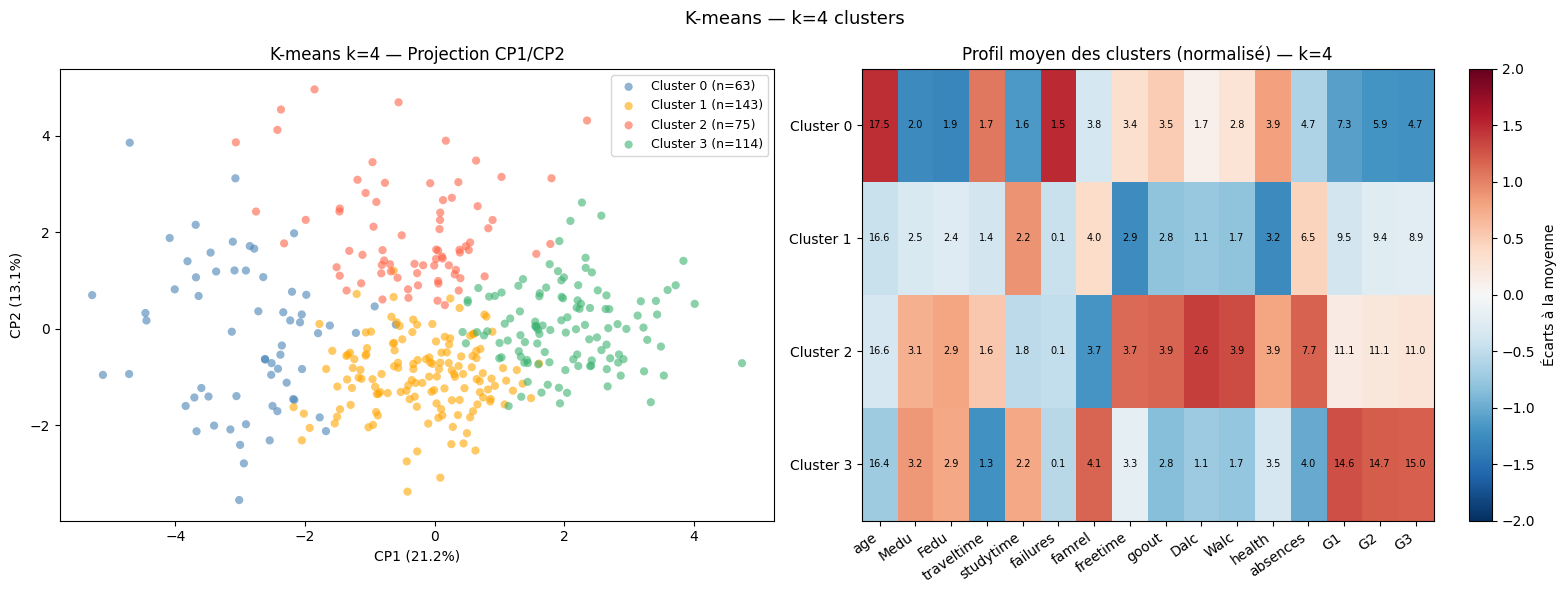

Taille des clusters (k=4) :
  Cluster 0 : 63 individus 9.71%
  Cluster 1 : 143 individus 22.03%
  Cluster 2 : 75 individus 11.56%
  Cluster 3 : 114 individus 17.57%



In [15]:
labels4 = plot_kmeans(X_pca9, X_pca2, 4, df_num, num_cols)

### k=4 
k=4 subdivise Cluster 2 en distinguant un profil très bonne note (G3≈14) séparé du reste

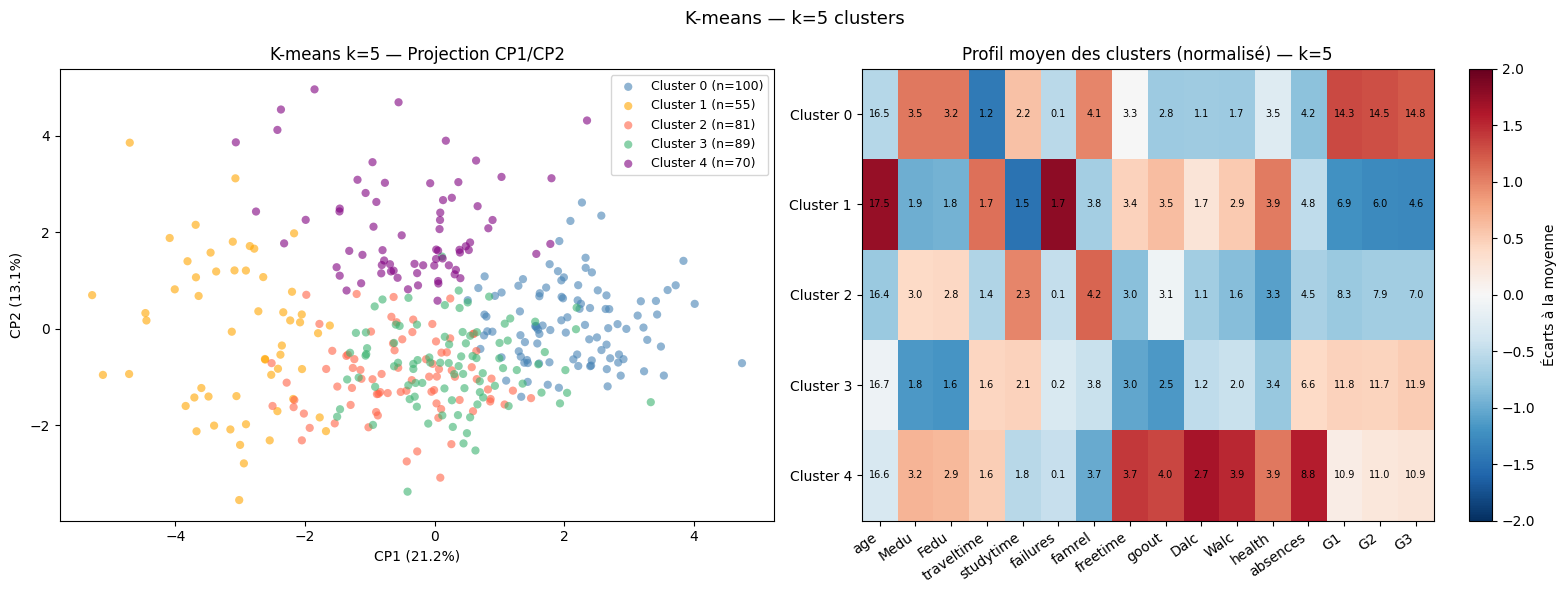

Taille des clusters (k=5) :
  Cluster 0 : 100 individus 15.41%
  Cluster 1 : 55 individus 8.47%
  Cluster 2 : 81 individus 12.48%
  Cluster 3 : 89 individus 13.71%
  Cluster 4 : 70 individus 10.79%



In [16]:
labels5 = plot_kmeans(X_pca9, X_pca2, 5, df_num, num_cols)

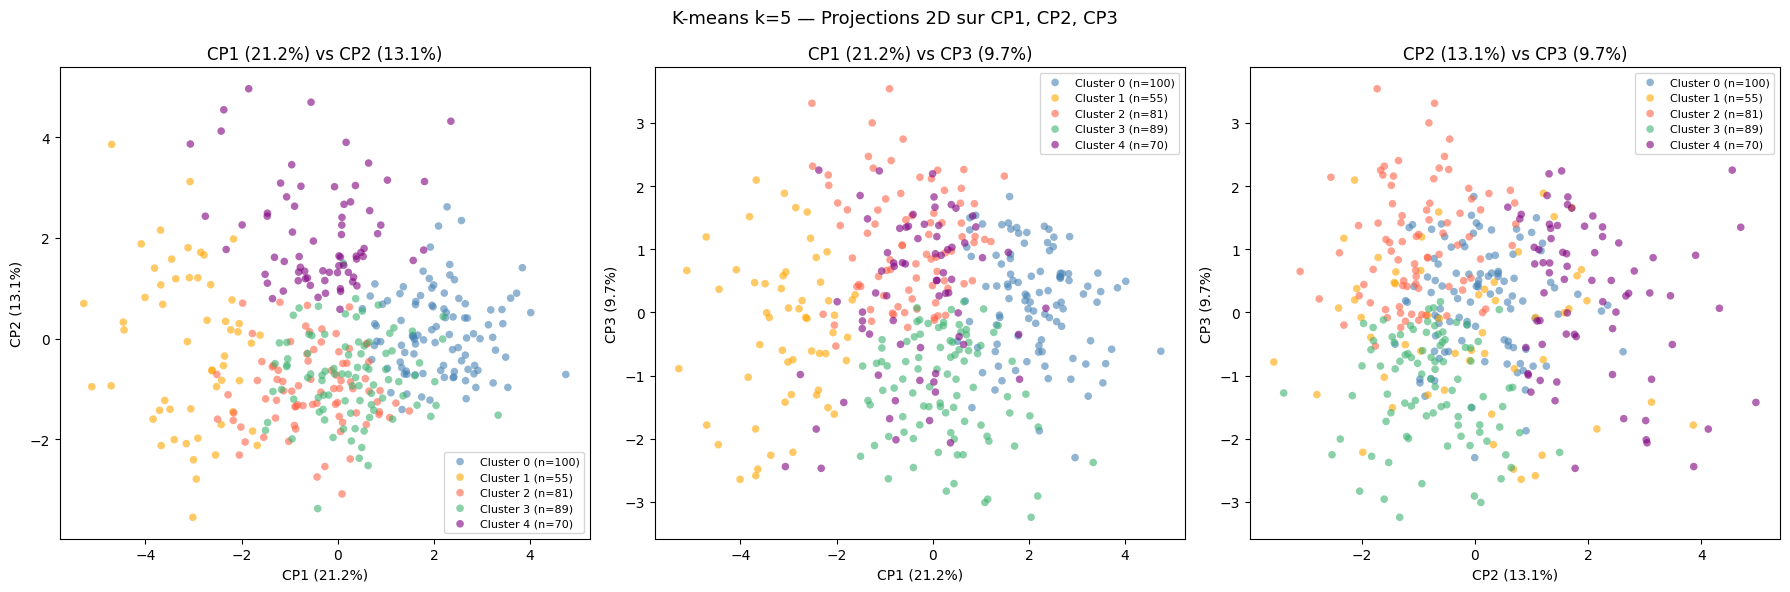

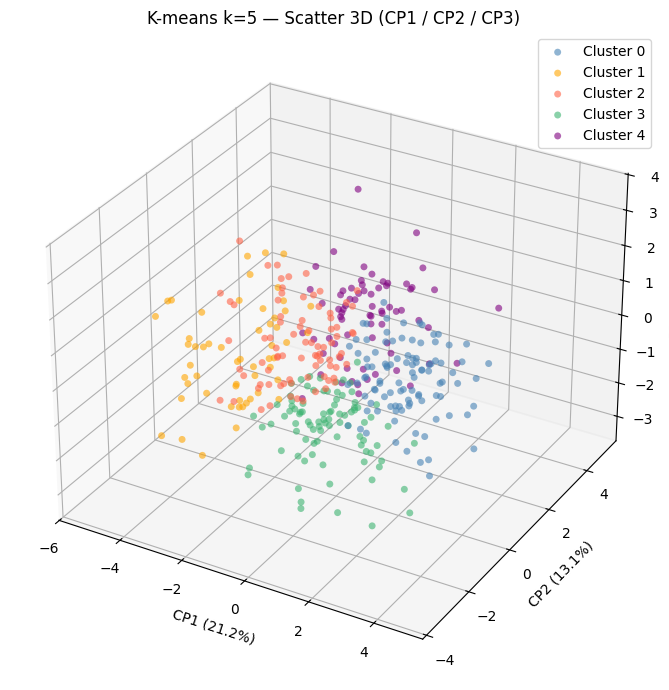

In [17]:
# ---- Visualisation k=5 : 3 projections 2D (CP1/CP2, CP1/CP3, CP2/CP3) + scatter 3D ----
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

km5 = KMeans(n_clusters=5, n_init=50, random_state=42)
labels5 = km5.fit_predict(X_pca9)

palette = ['steelblue', 'orange', 'tomato', 'mediumseagreen', 'purple']
var = pca3.explained_variance_ratio_

# --- 3 projections 2D ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [(0, 1), (0, 2), (1, 2)]
labels_cp = [f'CP{i+1} ({var[i]*100:.1f}%)' for i in range(3)]

for ax, (i, j) in zip(axes, pairs):
    for c in range(5):
        mask = labels5 == c
        ax.scatter(X_pca3[mask, i], X_pca3[mask, j],
                   c=palette[c], label=f'Cluster {c} (n={mask.sum()})',
                   alpha=0.6, s=30, edgecolors='none')
    ax.set_xlabel(labels_cp[i])
    ax.set_ylabel(labels_cp[j])
    ax.set_title(f'{labels_cp[i]} vs {labels_cp[j]}')
    ax.legend(fontsize=8)

plt.suptitle('K-means k=5 — Projections 2D sur CP1, CP2, CP3', fontsize=13)
plt.tight_layout()
plt.show()

# --- Scatter 3D ---
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for c in range(5):
    mask = labels5 == c
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               c=palette[c], label=f'Cluster {c}', alpha=0.6, s=25, edgecolors='none')

ax.set_xlabel(labels_cp[0])
ax.set_ylabel(labels_cp[1])
ax.set_zlabel(labels_cp[2])
ax.set_title('K-means k=5 — Scatter 3D (CP1 / CP2 / CP3)')
ax.legend()
plt.tight_layout()
plt.show()


### k=5 
les clusters commencent à être trop petits (n=55) pour être interprétables, mais isole clairement un profil "décrocheur" (beaucoup d'absences, Dalc/Walc élevé, G3 faible)

## 7. Comparaison des partitions

In [18]:
from sklearn.metrics import adjusted_rand_score

print("Similarité entre partitions (Adjusted Rand Index) :")
print(f"  k=3 vs k=4 : {adjusted_rand_score(labels3, labels4):.3f}")
print(f"  k=3 vs k=5 : {adjusted_rand_score(labels3, labels5):.3f}")
print(f"  k=4 vs k=5 : {adjusted_rand_score(labels4, labels5):.3f}")
print()
print("(0 = indépendantes, 1 = identiques)")


Similarité entre partitions (Adjusted Rand Index) :
  k=3 vs k=4 : 0.531
  k=3 vs k=5 : 0.402
  k=4 vs k=5 : 0.602

(0 = indépendantes, 1 = identiques)


---
## 8. ACP + K-means étendu — toutes les variables (quantitatives + binaires + catégorielles)

On encode les **8 variables booléennes** (0/1) et les **9 variables catégorielles** (one-hot, drop=first) pour obtenir 42 variables au total, puis on refait l'ACP complète.

> **Note :** l'ACP sur des variables encodées one-hot est une approximation (FAMD serait plus rigoureux), mais reste courante et interprétable après standardisation.


In [19]:
# ---- Encodage complet ----
from sklearn.preprocessing import OneHotEncoder

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'nursery', 'internet', 'romantic']
cat_cols  = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']

bool_df = student_mat[bool_cols].apply(lambda c: (c == 'yes').astype(int))

enc = OneHotEncoder(sparse_output=False, drop='first')
cat_enc = pd.DataFrame(
    enc.fit_transform(student_mat[cat_cols]),
    columns=enc.get_feature_names_out(cat_cols)
)

df_full = pd.concat([
    student_mat[num_cols].reset_index(drop=True),
    bool_df.reset_index(drop=True),
    cat_enc.reset_index(drop=True)
], axis=1).dropna()

all_cols = list(df_full.columns)
X_full = StandardScaler().fit_transform(df_full)

print(f"Dimensions : {df_full.shape}  ({df_full.shape[0]} individus, {df_full.shape[1]} variables)")
print(f"  — {len(num_cols)} quantitatives")
print(f"  — {len(bool_cols)} booléennes")
print(f"  — {df_full.shape[1] - len(num_cols) - len(bool_cols)} catégorielles encodées")


Dimensions : (395, 42)  (395 individus, 42 variables)
  — 16 quantitatives
  — 8 booléennes
  — 18 catégorielles encodées


### Éboulis — 42 variables

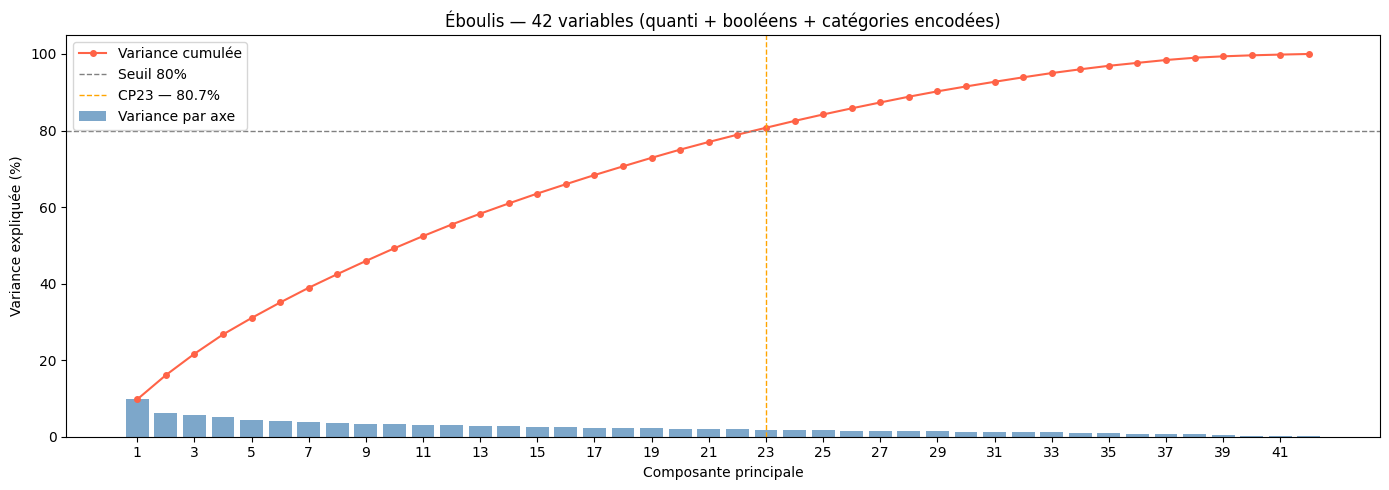

Composantes nécessaires pour 80% de variance : 23


In [20]:
# ---- Éboulis ----
pca_full2 = PCA()
pca_full2.fit(X_full)

exp2  = pca_full2.explained_variance_ratio_
cum2  = np.cumsum(exp2)
n_80  = int(np.argmax(cum2 >= 0.80)) + 1

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(1, len(exp2)+1), exp2 * 100, color='steelblue', alpha=0.7, label='Variance par axe')
ax.plot(range(1, len(exp2)+1), cum2 * 100, 'o-', color='tomato', markersize=4, label='Variance cumulée')
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='Seuil 80%')
ax.axvline(n_80, color='orange', linestyle='--', linewidth=1, label=f'CP{n_80} — {cum2[n_80-1]*100:.1f}%')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax.set_title(f'Éboulis — 42 variables (quanti + booléens + catégories encodées)')
ax.set_xticks(range(1, len(exp2)+1, 2))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Composantes nécessaires pour 80% de variance : {n_80}")


### Cercle des corrélations — CP1/CP2

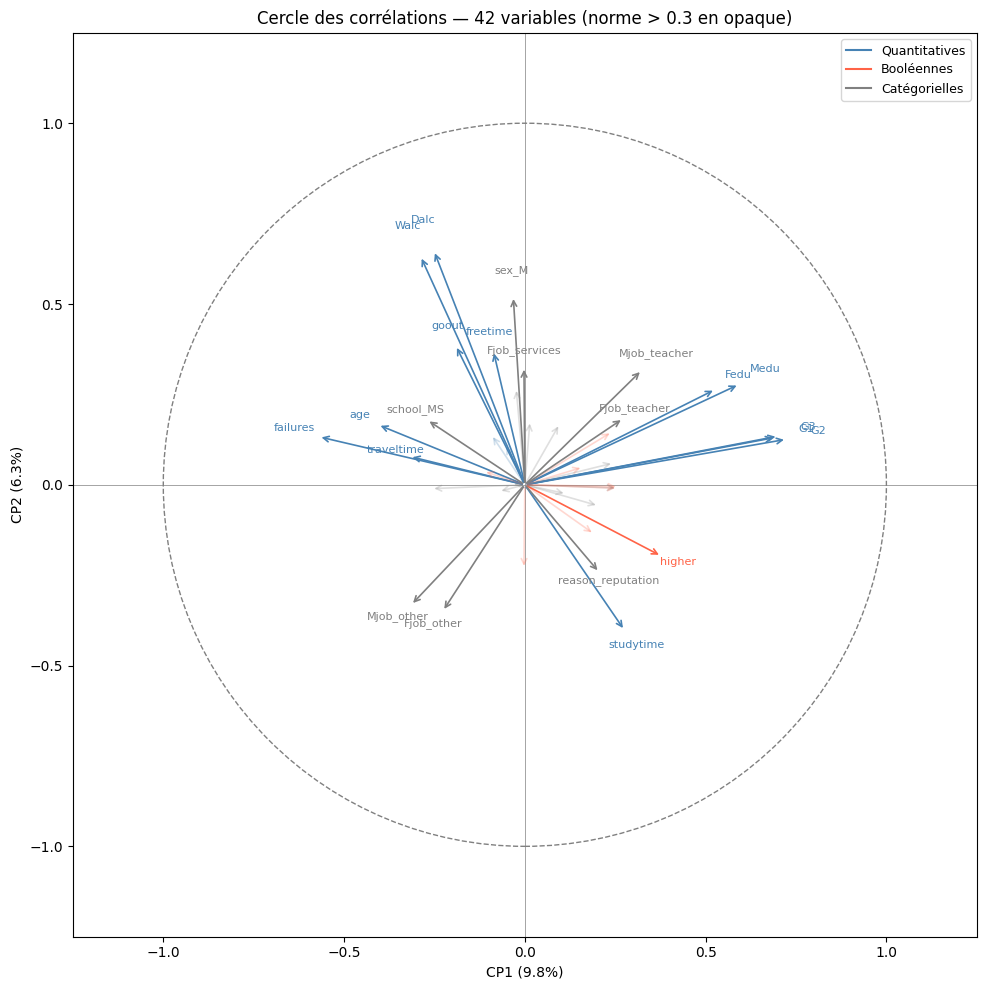

In [21]:
# ---- Cercle des corrélations (CP1/CP2) ----
pca2_full = PCA(n_components=2)
X_pca2_full = pca2_full.fit_transform(X_full)
coords2 = pca2_full.components_.T * np.sqrt(pca2_full.explained_variance_)

# On affiche uniquement les variables les mieux représentées (norme > 0.3)
norms = np.linalg.norm(coords2, axis=1)
mask_top = norms > 0.3

fig, ax = plt.subplots(figsize=(10, 10))
for i, var in enumerate(all_cols):
    color = 'steelblue' if var in num_cols else ('tomato' if var in bool_cols else 'gray')
    alpha = 1.0 if mask_top[i] else 0.25
    ax.annotate("", xy=(coords2[i,0], coords2[i,1]), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2, alpha=alpha))
    if mask_top[i]:
        ax.text(coords2[i,0]*1.12, coords2[i,1]*1.12, var, fontsize=8, ha='center', color=color)

for label, color in [('Quantitatives','steelblue'),('Booléennes','tomato'),('Catégorielles','gray')]:
    ax.plot([], [], color=color, label=label)
ax.legend(fontsize=9)

cercle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(cercle)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_xlabel(f'CP1 ({pca2_full.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'CP2 ({pca2_full.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cercle des corrélations — 42 variables (norme > 0.3 en opaque)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


### K-means k=3, 4, 5 sur les 23 composantes

In [22]:
# ---- Réduction à 23 composantes (80.7% de variance) ----
N_COMP_FULL = n_80
pca_full_red = PCA(n_components=N_COMP_FULL, random_state=42)
X_pca_full   = pca_full_red.fit_transform(X_full)

pca3_full = PCA(n_components=3)
X_pca3_full = pca3_full.fit_transform(X_full)

print(f"Espace réduit : {X_pca_full.shape}  ({pca_full_red.explained_variance_ratio_.sum()*100:.1f}% variance)")


Espace réduit : (395, 23)  (80.7% variance)


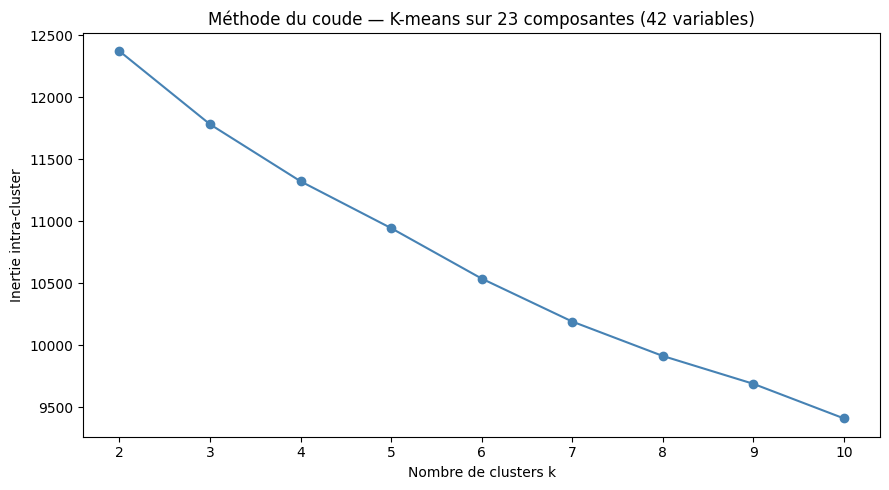

In [23]:
# ---- Méthode du coude ----
inertias_full = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_pca_full)
    inertias_full.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertias_full, 'o-', color='steelblue')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude — K-means sur 23 composantes (42 variables)')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()


On va choisir arbitrairement le K

In [24]:
# ---- Fonction K-means étendue ----
# Profil sur les 16 variables quantitatives (lisibilité) + sexe + higher
cols_profil = num_cols + ['higher', 'sex_F']  # sex_F = 1 si fille

def plot_kmeans_full(X_pca_full, X_pca3, k, df_full, num_cols):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X_pca_full)

    palette = ['steelblue', 'orange', 'tomato', 'mediumseagreen', 'purple']
    var3 = pca3_full.explained_variance_ratio_

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    # Scatter CP1/CP2
    for c in range(k):
        mask = labels == c
        axes[0].scatter(X_pca3[mask, 0], X_pca3[mask, 1],
                        c=palette[c], label=f'Cluster {c} (n={mask.sum()})',
                        alpha=0.6, s=35, edgecolors='none')
    axes[0].set_xlabel(f'CP1 ({var3[0]*100:.1f}%)')
    axes[0].set_ylabel(f'CP2 ({var3[1]*100:.1f}%)')
    axes[0].set_title(f'K-means k={k} — CP1/CP2 (42 vars)')
    axes[0].legend(fontsize=9)

    # Profil heatmap sur variables quantitatives + higher + sex
    df_tmp = df_full.copy()
    df_tmp['cluster'] = labels
    profile = df_tmp.groupby('cluster')[num_cols].mean()
    pn = (profile - profile.mean()) / profile.std()

    im = axes[1].imshow(pn.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    axes[1].set_xticks(range(len(num_cols)))
    axes[1].set_xticklabels(num_cols, rotation=35, ha='right')
    axes[1].set_yticks(range(k))
    axes[1].set_yticklabels([f'Cluster {i}' for i in range(k)])
    axes[1].set_title(f'Profil moyen — variables quantitatives (k={k})')
    plt.colorbar(im, ax=axes[1], label='Écarts à la moyenne')
    for i in range(k):
        for j in range(len(num_cols)):
            axes[1].text(j, i, f'{profile.values[i,j]:.1f}',
                         ha='center', va='center', fontsize=7)

    plt.suptitle(f'K-means étendu — k={k} (42 variables)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Profil des variables non-quantitatives
    cols_bool = [c for c in bool_cols if c in df_tmp.columns]
    if cols_bool:
        profil_bool = df_tmp.groupby('cluster')[cols_bool].mean().round(2)
        print(f"Profil booléens (proportion par cluster) :")
        print(profil_bool.to_string())
    print()
    return labels


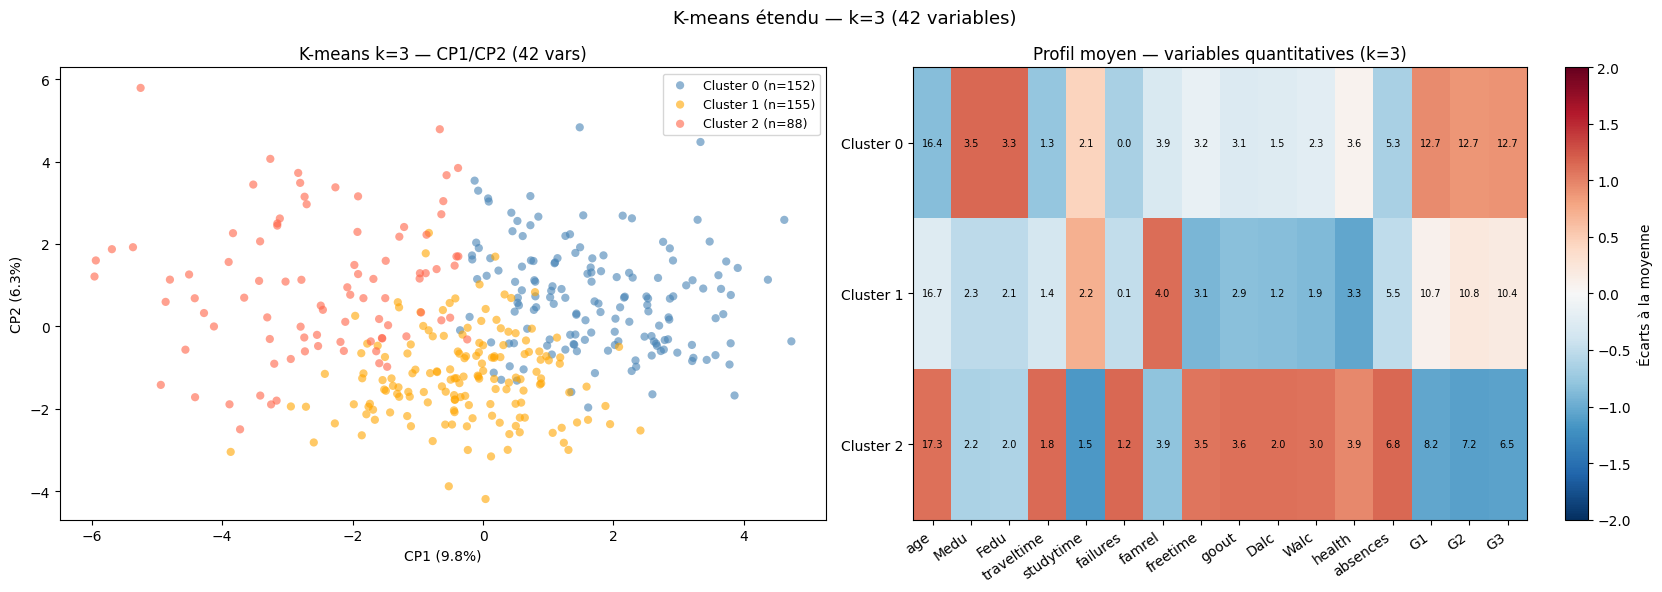

Profil booléens (proportion par cluster) :
         schoolsup  famsup  paid  activities  higher  nursery  internet  romantic
cluster                                                                          
0             0.10    0.74  0.59        0.64    1.00     0.88      0.95      0.30
1             0.19    0.53  0.42        0.43    1.00     0.76      0.74      0.30
2             0.08    0.53  0.30        0.43    0.77     0.70      0.81      0.44



In [25]:
labels_full3 = plot_kmeans_full(X_pca_full, X_pca3_full, 3, df_full, num_cols)

### Analyse 

#### Interpretation des axes 
- CP1 (droite) : G1, G2, G3, Medu, Fedu, higher → axe "réussite et capital familial"
- CP1 (gauche) : failures, age, traveltime, school_MS → axe "difficulté scolaire"
- CP2 (haut) : Dalc, Walc, goout, freetime → axe "comportement festif"


#### Cluster 0 (n=152) : 
- higher=100%, internet=95%, paid=59%, activities=64% (en général coûteuse) (taux le plus élévé) → élèves bien équipés et ambitieux 
- On remarque également que dans ce cluster, on retrouve les meilleurs résultat (à droite de l'axe), et c'est les élèves avec les parents possédant les meilleurs éducations.
- Ils ont le moins d'absences
- Ils ont quasiment pas d'echec (selon la moyenne 0) -> excellence académique
- C'est également les plus jeunes

#### Cluster 1 (n=155) 
- higher=100%, moins d'internet (74%), moins de cours payants → profil intermédiaire ()
- Ils ont des résultat moyens
- Bonne relation familiales
- C'est le groupe qui sort le moins, qui a le moins de temps libre, qui consomme le moins d'alcool. 


#### Cluster 2 (n=88) 
- higher=77% seulement → seul groupe où des élèves ne visent pas le supérieur, plus de romantic (44%) donc plus distrait
- C'est les plus vieux et également ceux qui possède des niveau d'éducation parentales les moins élevées
- C'est les éleves les plus en échecs scolaires (seuls groupes avec un niveau de failure qui n'est pas 0) et également des très mauvais résultat scolaires.
- Groupe très festifs avec la plus haute consommations d'alcool, le plus de sorties, de temps libre et nombre d'absence. 
- Ceux qui ont également la meilleurs santé ????

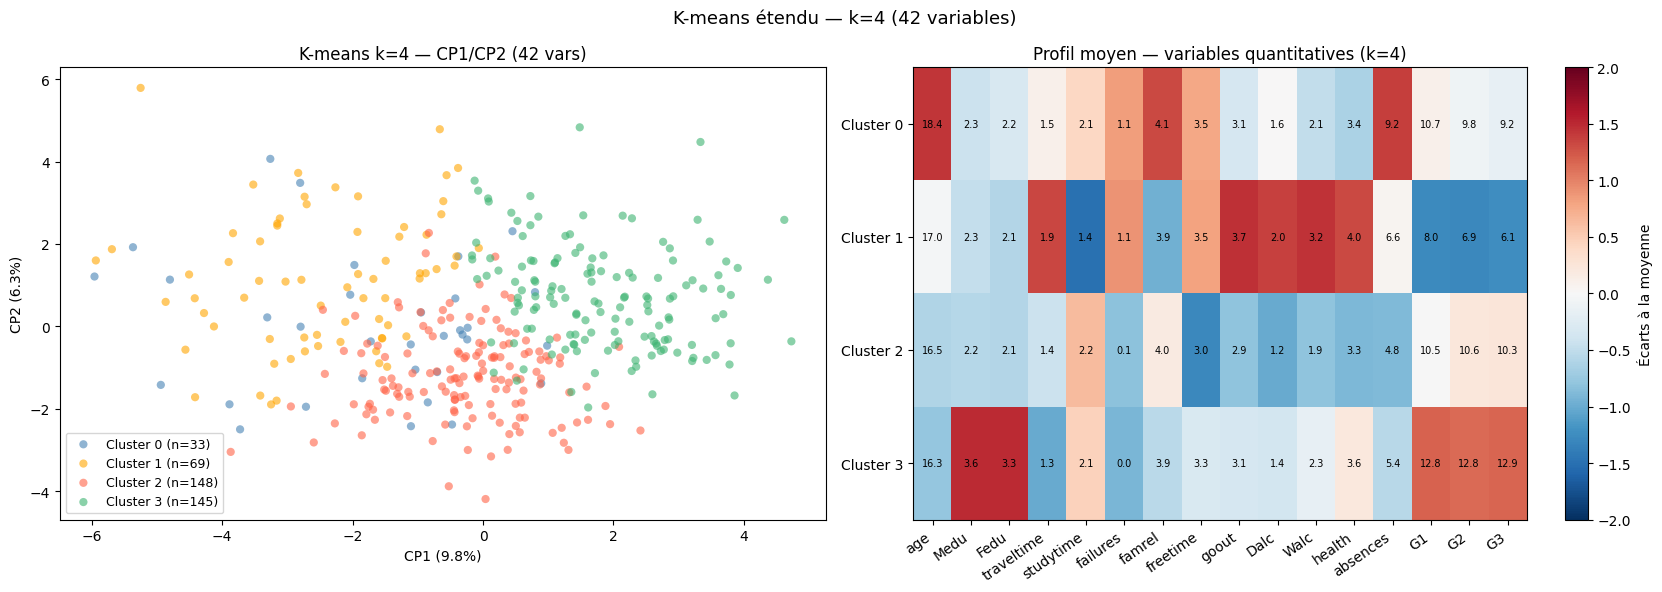

Profil booléens (proportion par cluster) :
         schoolsup  famsup  paid  activities  higher  nursery  internet  romantic
cluster                                                                          
0             0.06    0.61  0.42        0.45    0.94     0.58      0.76      0.55
1             0.09    0.54  0.25        0.46    0.74     0.74      0.84      0.41
2             0.20    0.54  0.45        0.41    1.00     0.78      0.73      0.28
3             0.10    0.72  0.58        0.64    1.00     0.89      0.95      0.31



In [26]:
labels_full4 = plot_kmeans_full(X_pca_full, X_pca3_full, 4, df_full, num_cols)

Ce cluster rentre plus dans les détails 

On peut remarquer que le **Cluster 0** et le **Cluster 1** sont à priori la division de l'ancien **Cluster 2** qui était le cluster des gens qui avait le taux d'échec le plus élévé. Ils possèdent tout les deux à peu près le même niveau d'éducation des parents, la quantité de temps libre élévé, et également un faible soutien éducatif. Mais qui ils vont diverger sur les paramètres suivant : 

**Cluster 0** (n=33):
- C'est le groupe le plus agé (en moyenne 2 ans plus vieux que le groupe le plus jeune), qui présente en moyenne 1 échec par élève. 
- Ce groupe ce démarque notament par de très bonne relation familiale mais surtout un nombre abérant d'absences. 
- On peut remarquer que ce groupe travaille autant que les cluster qui réussisent mais présente toute de même de mauvais résultats.
- Ce groupe possède un soutien élévé de la famille 
- Ce groupe est également aidé avec des cours payé
- Ce groupe présente une envie important d'aller dans le supérieur
- Ce groupe n'a pas beaucoup d'accès à internet (théorie de la pauvreté)
- Ce groupe est très romantic ce qui pourrait justifié le nombre d'absence 

**Cluster 1** (n=69): 
- Ce groupe lui est moins agé et représente ceux qui rate beaucoup (autant que le Cluster 0), mais cette fois avec le plus haut score de sorties, la plus haute consommation d'alcool, notament en en semaine en étant très loin de la moyenne.
- Ils possèdent également de très loin les moins bon résultats et ne travaille pas du tout avec un "studytime" très faible (pas loin du minimum). C'est également les étudiants qui ont le plus de trajet. 
- Ce groupe possède le plus faible soutien de la famille avec le **Cluster 2**
- Ce groupe n'a pas soutient en dehors des cours.
- Ce groupe ne présente la plus faible ambition d'aller dans le supérieur 
- Ce sont en très grande majorité des hommes (70%)


Une théorie peut donc se dégager de cette première analyse. Le **Cluster 2** du K=3-Means précédent s'est divisé en 2 afin de faire apparaitre 2 groupes :
- Le premier groupe est un groupe en décrochage scolaire avec de mauvais résultats, un taux d'échec élévé mais tout de même une volonté de réussir grâce à divers facteurs comme des cours payé, du soutiens extra-scolaire et également une beaucoup de travail (studytime). A noté que ce groupe présente une minorité (~10% de la population total donc à prendre avec des pincettes)
- Le deuxième groupe est un groupe en décrochage scolaire volontaire ne présentant aucune volonté de réussir en sortant et buvant beaucoup et en travaillant peu.

**Cluster 2** : c'est le groupe moyen qu'on a vu la dernière fois en **Cluster 1** (surtout des femmes) (n=148)

**Cluster 3** : c'est le groupe d'excellence académique qu'on a vu la dernière fois en **Cluster 0** (n=145)

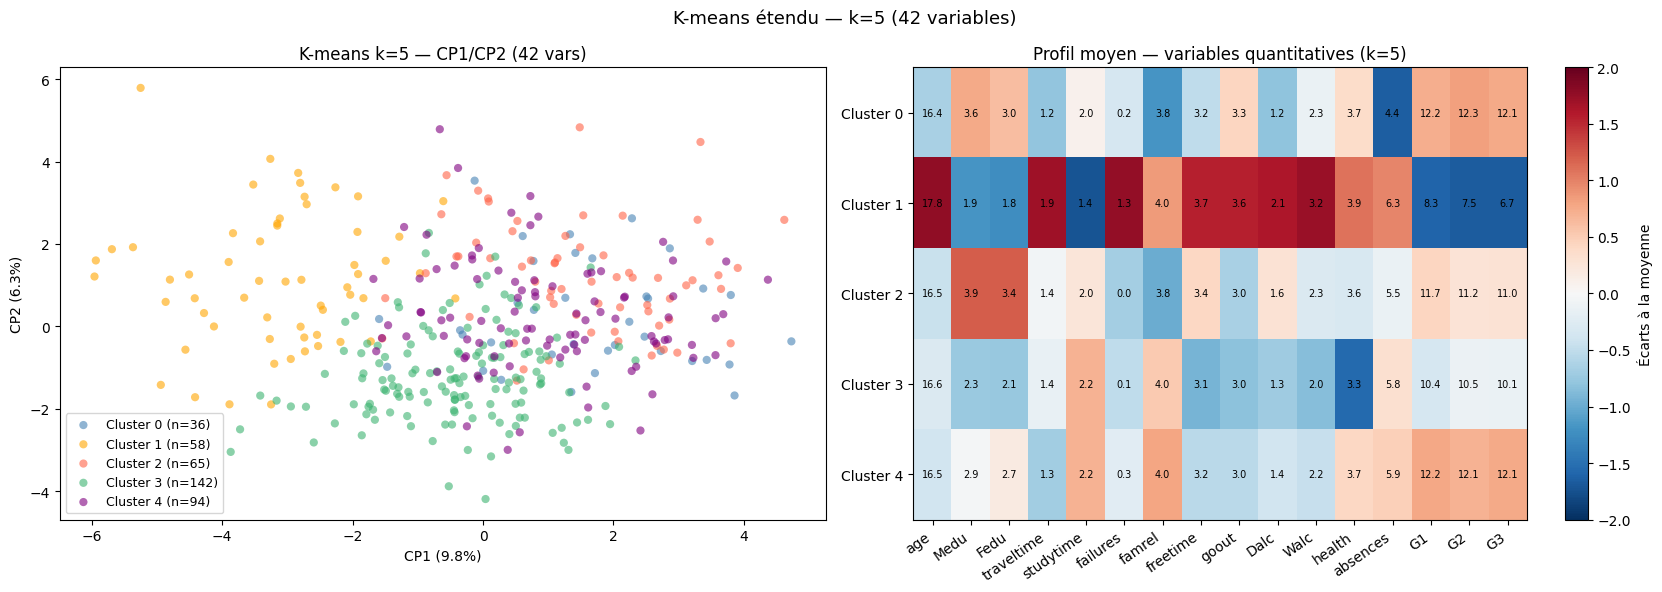

Profil booléens (proportion par cluster) :
         schoolsup  famsup  paid  activities  higher  nursery  internet  romantic
cluster                                                                          
0             0.06    0.78  0.61        0.53    1.00     0.89      0.94      0.42
1             0.07    0.45  0.16        0.43    0.67     0.66      0.72      0.41
2             0.05    0.71  0.60        0.63    0.98     0.88      0.92      0.32
3             0.20    0.56  0.43        0.46    1.00     0.76      0.75      0.30
4             0.15    0.67  0.53        0.54    1.00     0.84      0.91      0.31



In [27]:
labels_full5 = plot_kmeans_full(X_pca_full, X_pca3_full, 5, df_full, num_cols)

On commence avec les cluster qui n'ont pas trop bougé : 

**Cluster 3** (n=142) : Le cluster moyen en majorité des femmes qui ne bougent pas. C'est le cluster le plus "fiable" — il provient quasi-entièrement de l'ancien **Cluster 2** du k=4 (123/148). Il conserve le même profil : femmes (68%), notes moyennes (G3≈10), peu d'alcool, `schoolsup` élevé (0.20 = le plus fort, signe de difficultés). `higher`=1.00.

**Cluster 1** (n=58) : Groupe en décrochage scolaire volontaire qui se dessine encore mieux (toujours une majorité d'hommes, 76%) mais on passe de 69 → 58. Ce cluster absorbe également une partie de l'ancien **Cluster 0** du k=4 (les décrocheurs plus âgés, 13 individus), formant ainsi un groupe homogène de décrocheurs. Il présente les caractéristiques les plus extrêmes du jeu de données : Medu/Fedu les plus bas (1.90/1.84), `higher`=**0.67** (le seul groupe sous les 70%), G3=**6.67** (le pire résultat), goout=3.55, Walc=3.21. Ces élèves ne bénéficient d'aucun soutien (`famsup`=0.45, `paid`=**0.16** — le plus bas de tous).

---

La vraie nouveauté de k=5 est la **fragmentation du groupe d'excellence** (ancien **Cluster 3** du k=4, n=145) qui se divise en trois sous-groupes distincts :

**Cluster 2** (n=55, vient de k=4 Cluster 3) : C'est le sous-groupe à **capital parental le plus élevé** de toute l'analyse — Medu=**3.94**, Fedu=**3.37** (les deux plus hauts). Ils ont de bons résultats (G3≈11) et sont en **majorité des hommes** (68%), ce qui tranche avec le cluster féminin voisin. Ils participent beaucoup aux activités extra-scolaires (`activities`=0.63) et ont accès à des cours payants (`paid`=0.60).

**Cluster 4** (n=55, vient de k=4 Cluster 3 + Cluster 2) : Profil intermédiaire entre excellence et moyenne — Medu=2.87, G3≈12.1, `higher`=1.00, `internet`=0.91. Légèrement féminin (59% F). Ce cluster est celui qui bénéficie le plus du soutien familial dans la durée (`famsup`=0.67, `paid`=0.53).

**Cluster 0** (n=36, vient de k=4 Cluster 3) : Le plus petit et le plus particulier — bonnes notes (G3≈12.1), fort soutien familial (`famsup`=0.78), accès aux cours payants (`paid`=0.61), mais `romantic`=**0.42** (le plus élevé après le Cluster 1). Ce groupe est légèrement féminin (58% F). L'hypothèse : ce sont des élèves bien soutenus mais dont la vie sentimentale pourrait influencer certains comportements (à rapprocher de la théorie romantic/absences).

---

**Synthèse de la redistribution k=4 → k=5 :**
- Le groupe de **décrochage** (k=4 C0 + C1) fusionne en un cluster encore plus homogène et extrême (k=5 C1)
- Le groupe **moyen féminin** (k=4 C2) reste stable → k=5 C3
- Le groupe **d'excellence** (k=4 C3) éclate en 3 sous-groupes selon le niveau d'éducation parentale et le genre


### Comparaison : clustering quantitatif seul vs etendu — k=3, 4, 5

On compare les partitions obtenues avec les **16 variables quantitatives** (9 composantes) et celles
obtenues avec les **42 variables completes** (23 composantes). L'Adjusted Rand Index (ARI) mesure
l'accord global ; les matrices K x K montrent, pour chaque cluster quantitatif, comment ses membres
se redistribuent dans le clustering etendu (lecture par ligne, normalisee en %). Les colonnes sont
reordonnees par matching optimal pour maximiser la diagonale.

ARI clustering quantitatif (16 vars) vs etendu (42 vars) :
  k=3 : ARI = 0.176
  k=4 : ARI = 0.245
  k=5 : ARI = 0.125

(0 = partitions independantes, 1 = identiques)


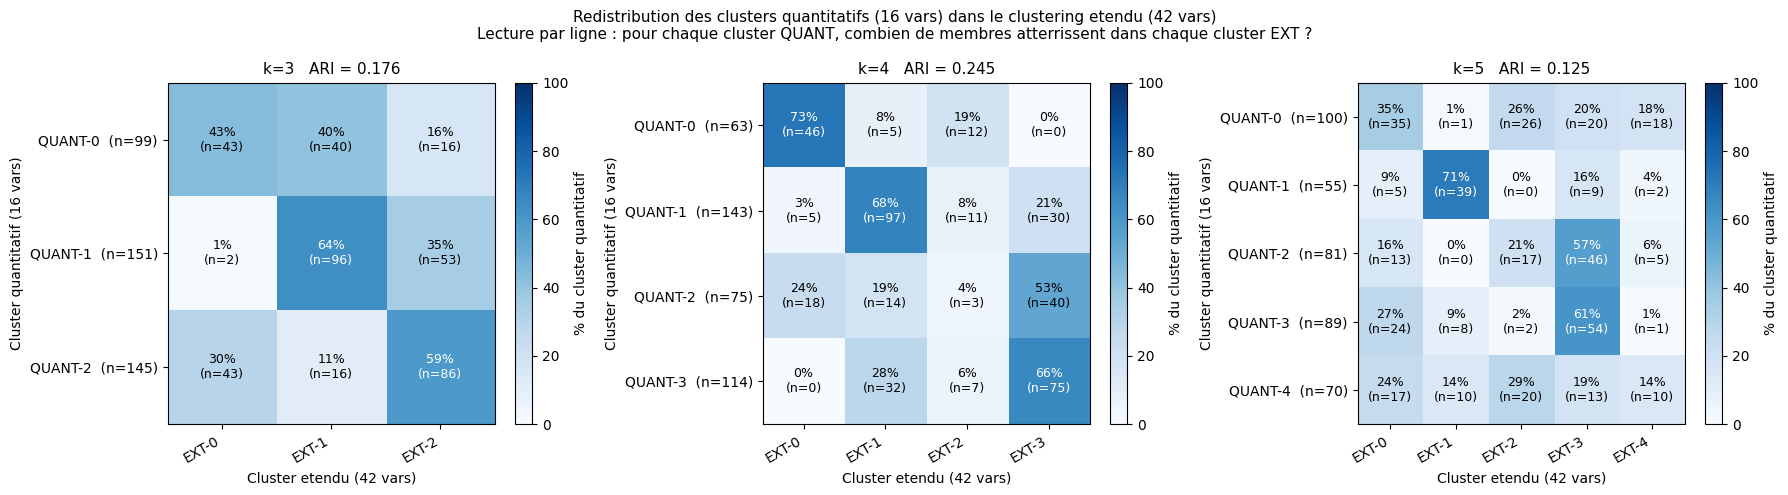

In [28]:
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment

# Recomputer les labels pour les 3 valeurs de k (les variables labels3/4/5 et labels_full3/4/5
# ont ete calculees dans les cellules precedentes du notebook)
quant_labels = {3: KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_pca9),
                4: KMeans(n_clusters=4, n_init=50, random_state=42).fit_predict(X_pca9),
                5: KMeans(n_clusters=5, n_init=50, random_state=42).fit_predict(X_pca9)}
full_labels  = {3: labels_full3, 4: labels_full4, 5: labels_full5}

print("ARI clustering quantitatif (16 vars) vs etendu (42 vars) :")
for k in [3, 4, 5]:
    ari = adjusted_rand_score(quant_labels[k], full_labels[k])
    print(f"  k={k} : ARI = {ari:.3f}")
print()
print("(0 = partitions independantes, 1 = identiques)")

# --- Grille de heatmaps K x K ---
def reorder_cols(ref, other, k):
    ct = pd.crosstab(ref, other).values
    _, col_ind = linear_sum_assignment(-ct)
    mapping = {old: new for new, old in enumerate(col_ind)}
    return np.array([mapping[l] for l in other])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, k in zip(axes, [3, 4, 5]):
    ref  = quant_labels[k]
    ext  = reorder_cols(ref, full_labels[k], k)
    ct   = pd.crosstab(ref, ext)
    pct  = ct.div(ct.sum(axis=1), axis=0) * 100
    ari  = adjusted_rand_score(ref, full_labels[k])

    im_ = ax.imshow(pct.values, cmap='Blues', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(k))
    ax.set_xticklabels([f'EXT-{i}' for i in range(k)], rotation=30, ha='right')
    ax.set_yticks(range(k))
    ax.set_yticklabels([f'QUANT-{i}  (n={(ref==i).sum()})' for i in range(k)])
    ax.set_title(f'k={k}   ARI = {ari:.3f}', fontsize=11)
    ax.set_xlabel('Cluster etendu (42 vars)')
    ax.set_ylabel('Cluster quantitatif (16 vars)')
    plt.colorbar(im_, ax=ax, label='% du cluster quantitatif')

    for i in range(k):
        for j in range(k):
            v = pct.values[i, j]
            ax.text(j, i, f'{v:.0f}%\n(n={ct.values[i,j]})',
                    ha='center', va='center', fontsize=9,
                    color='white' if v > 55 else 'black')

fig.suptitle(
    'Redistribution des clusters quantitatifs (16 vars) dans le clustering etendu (42 vars)\n'
    'Lecture par ligne : pour chaque cluster QUANT, combien de membres atterrissent dans chaque cluster EXT ?',
    fontsize=11)
plt.tight_layout()
plt.show()


### Influence des métiers parentaux par cluster

Pour chaque cluster (k=3 et k=4 du K-means étendu), on calcule la proportion d'élèves dont la mère
ou le père exerce chaque métier. La ligne *Pop.* rappelle la distribution globale pour référence.


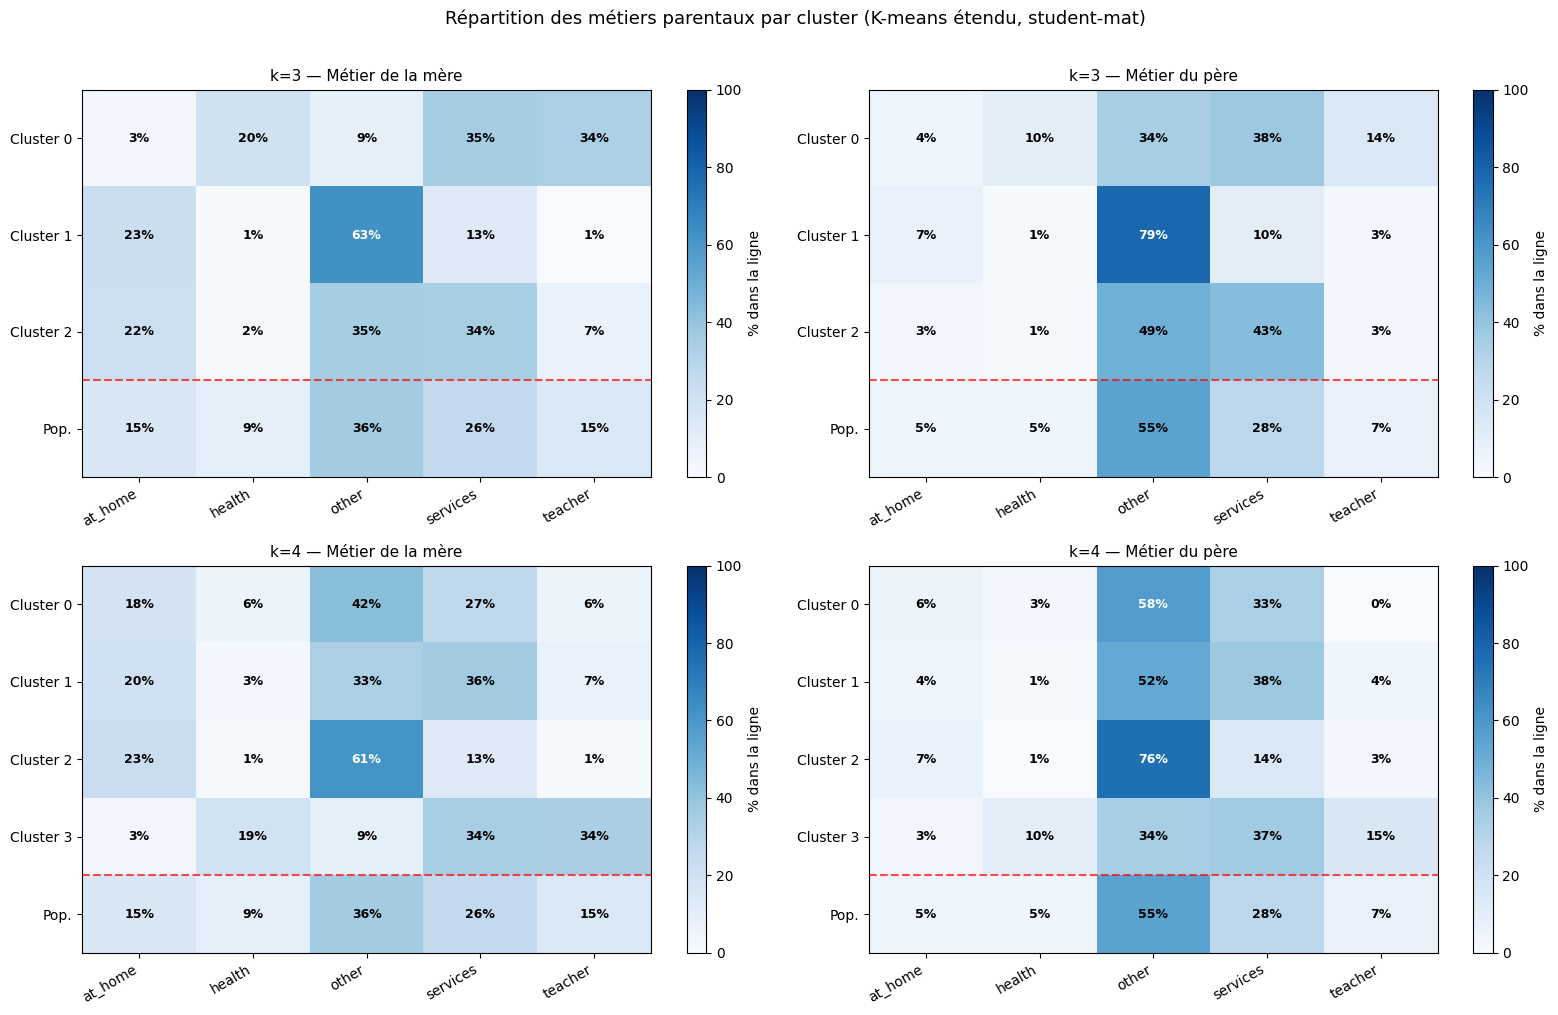

In [29]:
# Répartition Mjob / Fjob par cluster du K-means étendu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

job_cats = ['at_home', 'health', 'other', 'services', 'teacher']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Répartition des métiers parentaux par cluster (K-means étendu, student-mat)',
    fontsize=13, y=1.01
)

for row_idx, (k, labels) in enumerate([(3, labels_full3), (4, labels_full4)]):
    df_m = student_mat.copy()
    df_m['cluster'] = labels

    for col_idx, (job_col, title) in enumerate([('Mjob', 'Métier de la mère'), ('Fjob', 'Métier du père')]):
        ax = axes[row_idx, col_idx]

        ct = pd.crosstab(df_m['cluster'], df_m[job_col]).reindex(columns=job_cats, fill_value=0)
        pct = ct.div(ct.sum(axis=1), axis=0) * 100

        # Population reference row
        pop = student_mat[job_col].value_counts(normalize=True).reindex(job_cats, fill_value=0) * 100
        pct_with_pop = pd.concat([pct, pop.rename('Pop.').to_frame().T])

        n_rows = pct_with_pop.shape[0]
        im = ax.imshow(pct_with_pop.values, cmap='Blues', aspect='auto', vmin=0, vmax=100)

        ax.set_xticks(range(len(job_cats)))
        ax.set_xticklabels(job_cats, rotation=30, ha='right', fontsize=10)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(
            [f'Cluster {i}' for i in range(k)] + ['Pop.'],
            fontsize=10
        )
        ax.set_title(f'k={k} — {title}', fontsize=11)

        for i in range(n_rows):
            for j in range(len(job_cats)):
                val = pct_with_pop.values[i, j]
                color = 'white' if val > 55 else 'black'
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')

        # Separator line before pop row
        ax.axhline(k - 0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
        plt.colorbar(im, ax=ax, label='% dans la ligne')

plt.tight_layout()
plt.show()


---
# Partie 2 — Dataset student-por (Portugais)

On applique **exactement la même méthode** que sur student-mat :

1. Encodage des variables booléennes (0/1) et catégorielles (one-hot, drop=first) → **42 variables**
2. Centrage-réduction + ACP complète
3. Conservation des composantes jusqu'à **80% de variance**
4. K-means avec **k=3, k=4 et k=5** sur les composantes retenues
5. Visualisation des profils complets (quantitatif + booléen + catégoriel)

Le dataset portugais contient **649 élèves** (vs 395 pour maths), même structure de variables.  
L'objectif est de voir si les mêmes groupes naturels émergent dans une population différente.


## 1. Chargement et encodage

In [30]:
# ---- Chargement student-por ----
student_por = pd.read_csv("../donnees/student-por.csv")

bool_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'nursery', 'internet', 'romantic']
cat_cols  = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']

bool_por = student_por[bool_cols].apply(lambda c: (c == 'yes').astype(int))
enc_por  = OneHotEncoder(sparse_output=False, drop='first')
cat_por  = pd.DataFrame(
    enc_por.fit_transform(student_por[cat_cols]),
    columns=enc_por.get_feature_names_out(cat_cols)
)

df_por = pd.concat([
    student_por[num_cols].reset_index(drop=True),
    bool_por.reset_index(drop=True),
    cat_por.reset_index(drop=True)
], axis=1).dropna()

all_cols_por = list(df_por.columns)
X_por = StandardScaler().fit_transform(df_por)

print(f"Dimensions : {df_por.shape}  ({df_por.shape[0]} individus, {df_por.shape[1]} variables)")


Dimensions : (649, 42)  (649 individus, 42 variables)


## 2. ACP — Éboulis

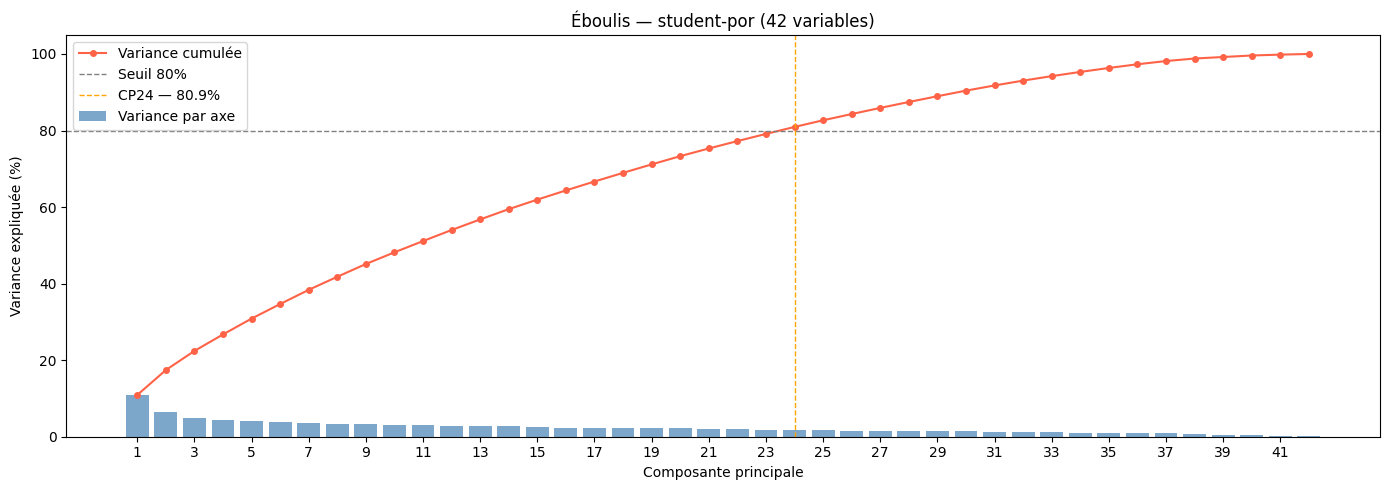

Composantes nécessaires pour 80% de variance : 24


In [31]:
# ---- Éboulis ----
pca_por = PCA()
pca_por.fit(X_por)

exp_por = pca_por.explained_variance_ratio_
cum_por = np.cumsum(exp_por)
n_80_por = int(np.argmax(cum_por >= 0.80)) + 1

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(1, len(exp_por)+1), exp_por * 100, color='steelblue', alpha=0.7, label='Variance par axe')
ax.plot(range(1, len(exp_por)+1), cum_por * 100, 'o-', color='tomato', markersize=4, label='Variance cumulée')
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='Seuil 80%')
ax.axvline(n_80_por, color='orange', linestyle='--', linewidth=1,
           label=f'CP{n_80_por} — {cum_por[n_80_por-1]*100:.1f}%')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax.set_title('Éboulis — student-por (42 variables)')
ax.set_xticks(range(1, len(exp_por)+1, 2))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Composantes nécessaires pour 80% de variance : {n_80_por}")


## 3. Cercle des corrélations (CP1/CP2)

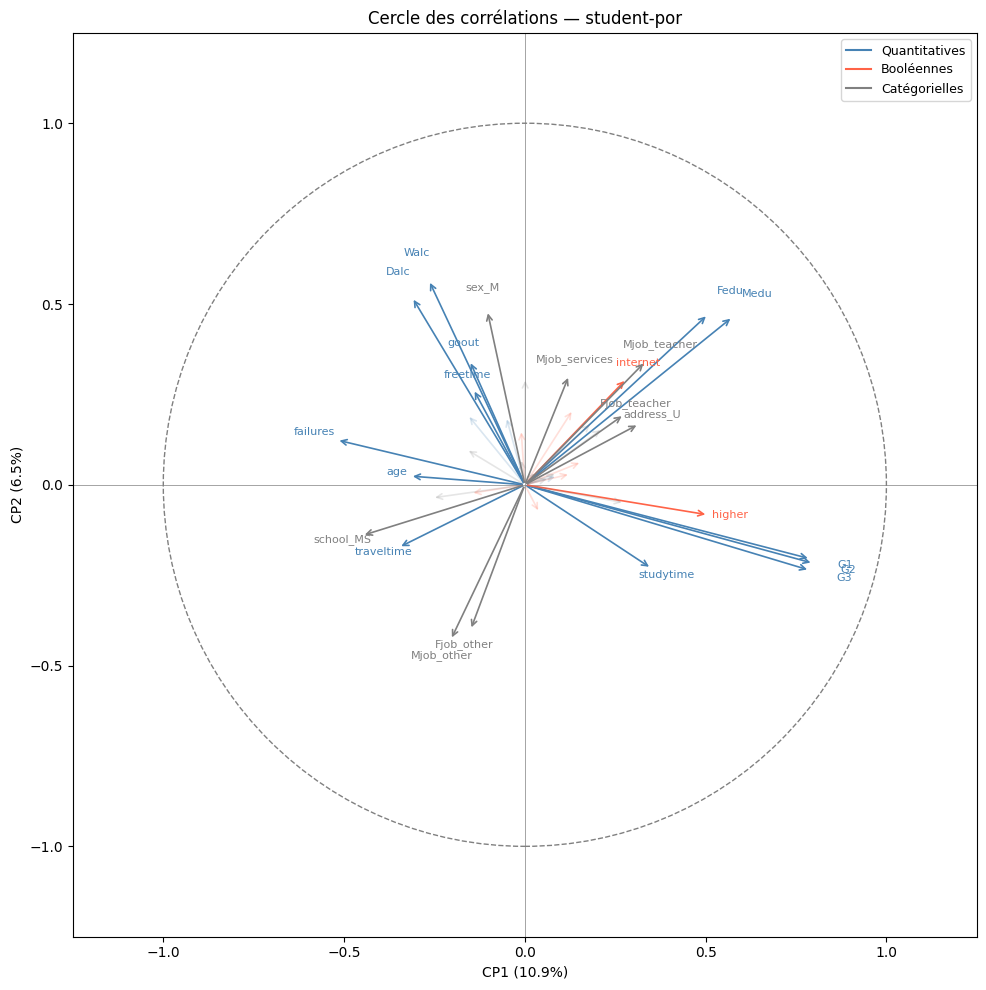

In [32]:
# ---- Cercle des corrélations ----
pca2_por = PCA(n_components=2)
X_pca2_por = pca2_por.fit_transform(X_por)
coords_por = pca2_por.components_.T * np.sqrt(pca2_por.explained_variance_)
norms_por  = np.linalg.norm(coords_por, axis=1)

fig, ax = plt.subplots(figsize=(10, 10))
for i, var in enumerate(all_cols_por):
    color = 'steelblue' if var in num_cols else ('tomato' if var in bool_cols else 'gray')
    alpha = 1.0 if norms_por[i] > 0.3 else 0.2
    ax.annotate("", xy=(coords_por[i, 0], coords_por[i, 1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2, alpha=alpha))
    if norms_por[i] > 0.3:
        ax.text(coords_por[i, 0]*1.12, coords_por[i, 1]*1.12, var,
                fontsize=8, ha='center', color=color)

for label, color in [('Quantitatives','steelblue'),('Booléennes','tomato'),('Catégorielles','gray')]:
    ax.plot([], [], color=color, label=label)
ax.legend(fontsize=9)
ax.add_patch(plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--'))
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25); ax.set_aspect('equal')
ax.set_xlabel(f'CP1 ({pca2_por.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'CP2 ({pca2_por.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cercle des corrélations — student-por')
plt.tight_layout()
plt.show()


## 4. Réduction + Méthode du coude

Espace réduit : (649, 24)  (80.9% variance)


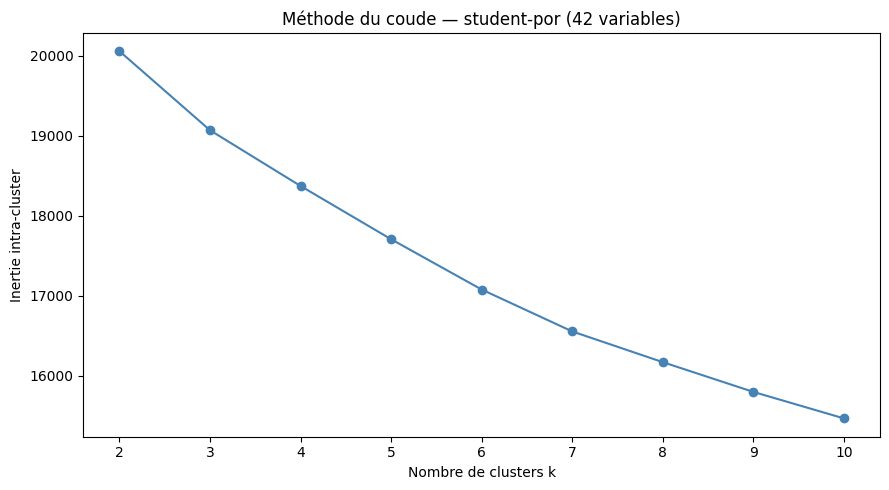

In [33]:
# ---- Réduction + elbow ----
pca_por_red = PCA(n_components=n_80_por, random_state=42)
X_por_red   = pca_por_red.fit_transform(X_por)

pca3_por  = PCA(n_components=3)
X_por_pca3 = pca3_por.fit_transform(X_por)

print(f"Espace réduit : {X_por_red.shape}  ({pca_por_red.explained_variance_ratio_.sum()*100:.1f}% variance)")

inertias_por = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_por_red)
    inertias_por.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertias_por, 'o-', color='steelblue')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie intra-cluster')
plt.title('Méthode du coude — student-por (42 variables)')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()


## 5. K-means k=3, k=4, k=5

In [34]:
# ---- Profils complets : layout 2x2 ----

def plot_profil_complet(df_full, labels, k, bool_cols, cat_cols, num_cols, raw_df=None, X_pca2=None, pca2_obj=None):
    df_tmp = df_full.copy()
    df_tmp['cluster'] = labels
    palette = ['steelblue', 'orange', 'tomato', 'mediumseagreen', 'purple']
    if raw_df is None:
        raw_df = student_mat

    fig, axes = plt.subplots(2, 2, figsize=(22, max(k * 1.2 + 4, 10)))

    # --- Haut gauche : Nuage de points CP1/CP2 ---
    ax = axes[0, 0]
    if X_pca2 is not None:
        for c in range(k):
            mask = labels == c
            ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                       c=palette[c], label=f'Cluster {c} (n={mask.sum()})',
                       alpha=0.55, s=25, edgecolors='none')
        v0 = pca2_obj.explained_variance_ratio_[0]*100 if pca2_obj else 0
        v1 = pca2_obj.explained_variance_ratio_[1]*100 if pca2_obj else 0
        ax.set_xlabel(f'CP1 ({v0:.1f}%)'); ax.set_ylabel(f'CP2 ({v1:.1f}%)')
        ax.legend(fontsize=9)
    ax.set_title('Nuage de points CP1 / CP2')

    # --- Haut droite : Variables quantitatives ---
    ax = axes[0, 1]
    profile_num = df_tmp.groupby('cluster')[num_cols].mean()
    pn = (profile_num - profile_num.mean()) / profile_num.std()
    im0 = ax.imshow(pn.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_xticks(range(len(num_cols)))
    ax.set_xticklabels(num_cols, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(k))
    ax.set_yticklabels([f'Cluster {i} (n={int((labels==i).sum())})' for i in range(k)])
    ax.set_title('Variables quantitatives (écarts à la moyenne)')
    plt.colorbar(im0, ax=ax, shrink=0.6)
    for i in range(k):
        for j in range(len(num_cols)):
            ax.text(j, i, f'{profile_num.values[i,j]:.1f}', ha='center', va='center', fontsize=6.5)

    # --- Bas gauche : Variables booléennes ---
    ax = axes[1, 0]
    profile_bool = df_tmp.groupby('cluster')[bool_cols].mean()
    im1 = ax.imshow(profile_bool.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(bool_cols)))
    ax.set_xticklabels(bool_cols, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(k))
    ax.set_yticklabels([f'Cluster {i}' for i in range(k)])
    ax.set_title('Variables booléennes (proportion)')
    plt.colorbar(im1, ax=ax, shrink=0.6)
    for i in range(k):
        for j in range(len(bool_cols)):
            ax.text(j, i, f'{profile_bool.values[i,j]:.2f}', ha='center', va='center', fontsize=7)

    # --- Bas droite : Modalité dominante catégorielles ---
    ax = axes[1, 1]
    cat_simple = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'reason', 'guardian']
    y_pos = np.arange(len(cat_simple))
    for c in range(k):
        idx = df_tmp[df_tmp['cluster'] == c].index
        sub = raw_df.iloc[idx]
        modes = [sub[col].value_counts(normalize=True).index[0] +
                 f' ({sub[col].value_counts(normalize=True).iloc[0]*100:.0f}%)'
                 for col in cat_simple]
        offset = y_pos - c * 0.18 + (k-1)*0.09
        ax.barh(offset, [1]*len(cat_simple), height=0.16,
                color=palette[c], alpha=0.7, label=f'Cluster {c}')
        for j, mode in enumerate(modes):
            ax.text(0.02, offset[j], mode, va='center', fontsize=7.5, color='black')
    ax.set_yticks(y_pos); ax.set_yticklabels(cat_simple, fontsize=9)
    ax.set_xlim(0, 1.5); ax.set_xticks([])
    ax.set_title('Modalité dominante par cluster')
    ax.legend(fontsize=8); ax.invert_yaxis()

    plt.suptitle(f'Profil complet des clusters — k={k}', fontsize=14)
    plt.tight_layout()
    plt.show()


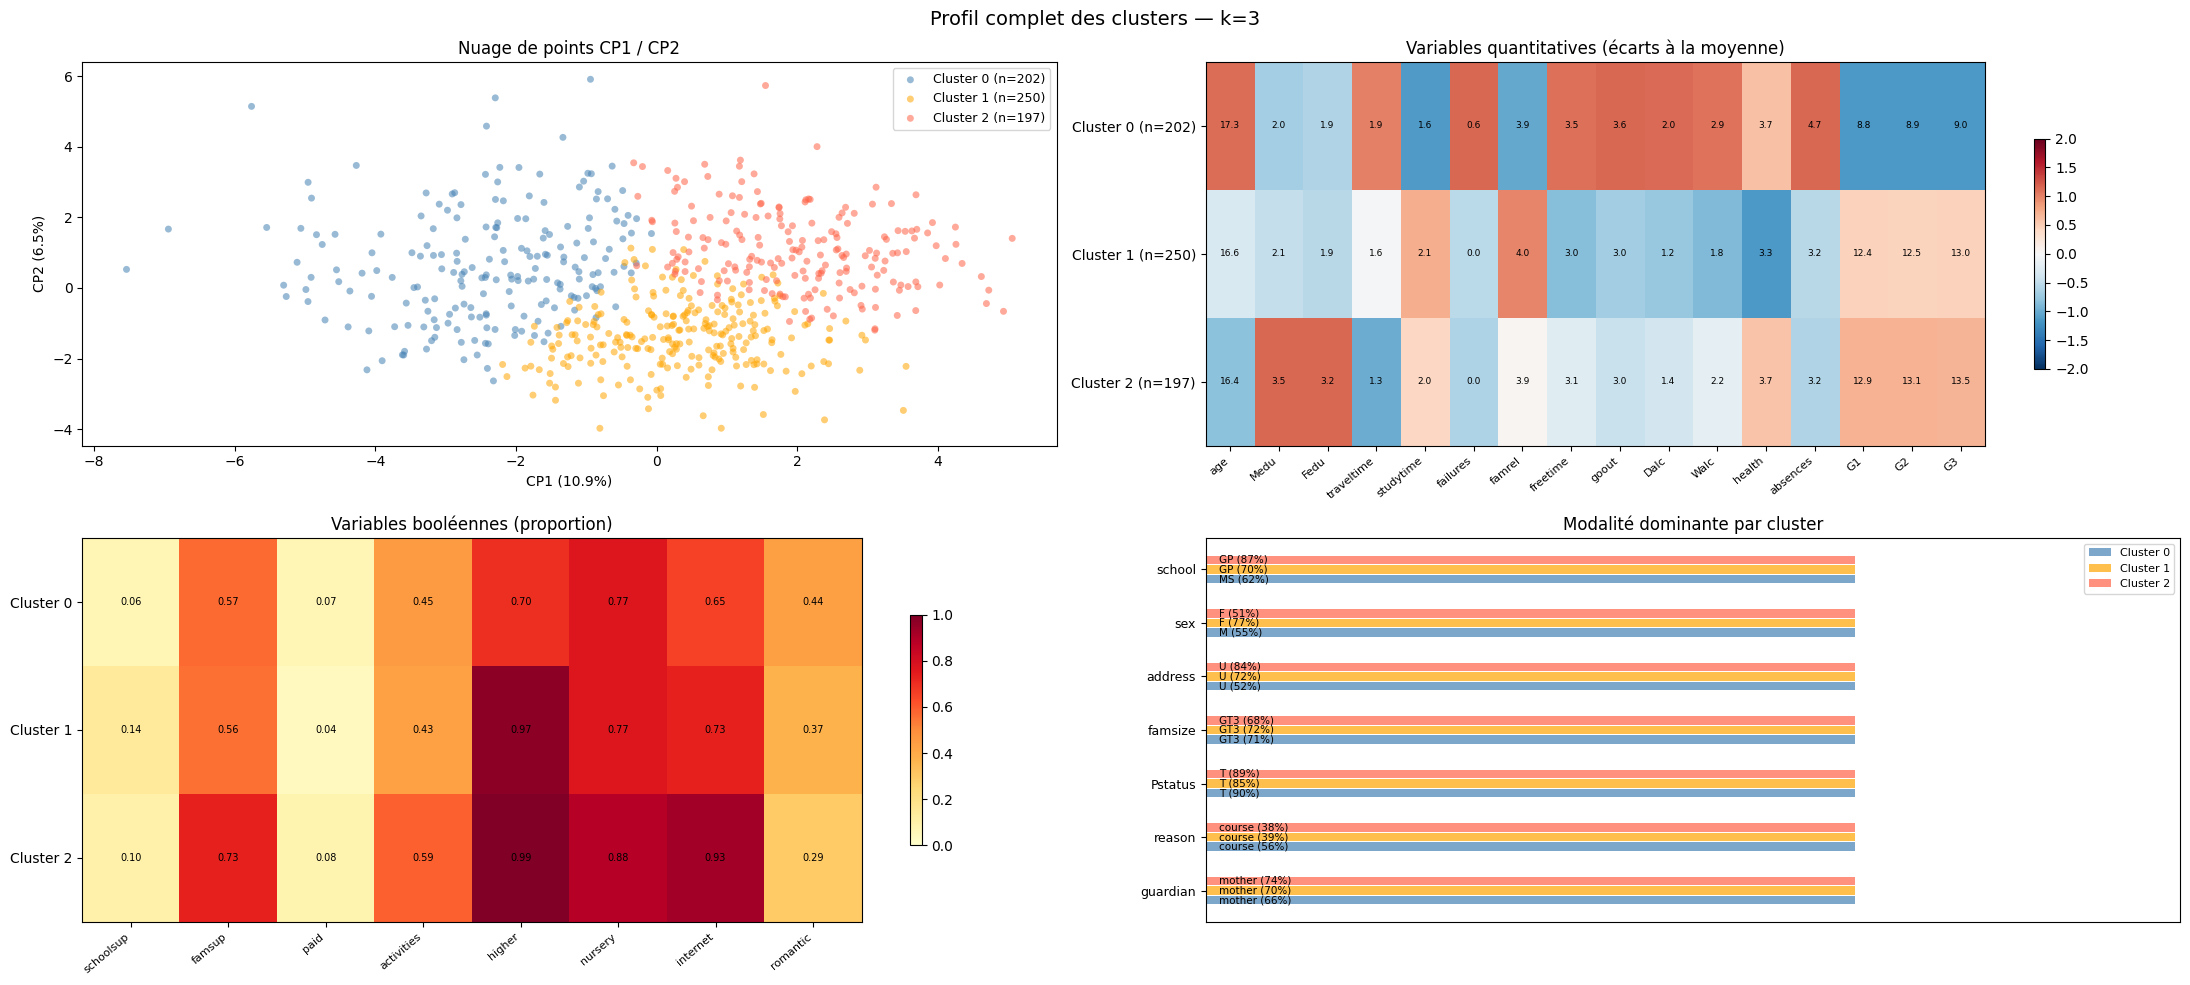

In [35]:
# ---- K-means k=3 — student-por ----
labels_por_3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit_predict(X_por_red)
plot_profil_complet(df_por, labels_por_3, 3, bool_cols, cat_cols, num_cols,
                    raw_df=student_por, X_pca2=X_pca2_por, pca2_obj=pca2_por)


### Analyse 

On tombe déjà sur des classes homogène (39/31/30)

#### Interpretation des axes 


#### Cluster 0 (n=202) **Décrochage Scolaire** (similaire a celui du dataset math): 
- Le groupe le plus vieux
- Le groupe qui sort le plus, qui a le plus de temps libre, qui boit le plus et également le plus d'absence
- C'est également le groupe qui travaille le moins et donc également le groupe avec les moins bon résultat (peu de soutient éducatif supplémentaire par l'école et la famille)
- Il vise très peu les études supérieur (70%) par rapport aux autres groupes
- C'est le groupe le plus romantique
- Faible accès à internet avec 65%

Par la suite pour parler du **Cluster 1** et du **Cluster 2**, on va dire ce qu'ils ont en commun et ce qu'ils ont en commun puis ce qui diverge

##### Points communs : 
- Age similaire
- Aucun echec scolaire passé
- même temps libre, nombre de sortie, consommation d'alcool en semaine et en week-end plus ou moins similaire
- Ils aspirent tous à faire des études dans le supérieur

#### Points divergents :
- Le groupe 2 à des notes légérement au dessus (0,5 de moyennes en plus sur chaque trimestre)
- Une meilleure santé (pas important)
- Boit légèrement plus le week-end
- Moins de trajet pour aller l'école
- Possède beaucoup de soutiens familiale (73% contre 56% sachant que le Cluster 0 possède 57%)
- Fait plus d'activité (signe d'excellence)
- Plus d'élève sont aller en nursery
- Meilleur accès à internet que les deux autres groupes (93% vs 73%)

#### Variables discriminante : 
- Il semble que ce qui fait réelement la différence c'est le niveau d'éducation des parents. D'un coté on a un groupe avec un niveau d'éducation très élévé (quasiement le maximum notament sur Medu)


#### Cluster 1 (n=250) **Hustlers**: 
- C'est le groupe avec de très bon résultat qui travail surement pas à cause d'une pression familiale (mes parents ont un haut niveau d'éducation donc je dois faire pareil)

#### Cluster 2 (n=197) **Excellent en Famille**:
- C'est le groupe d'excellence académique un peu héréditaire avec pas mal de soutiens de la famille 

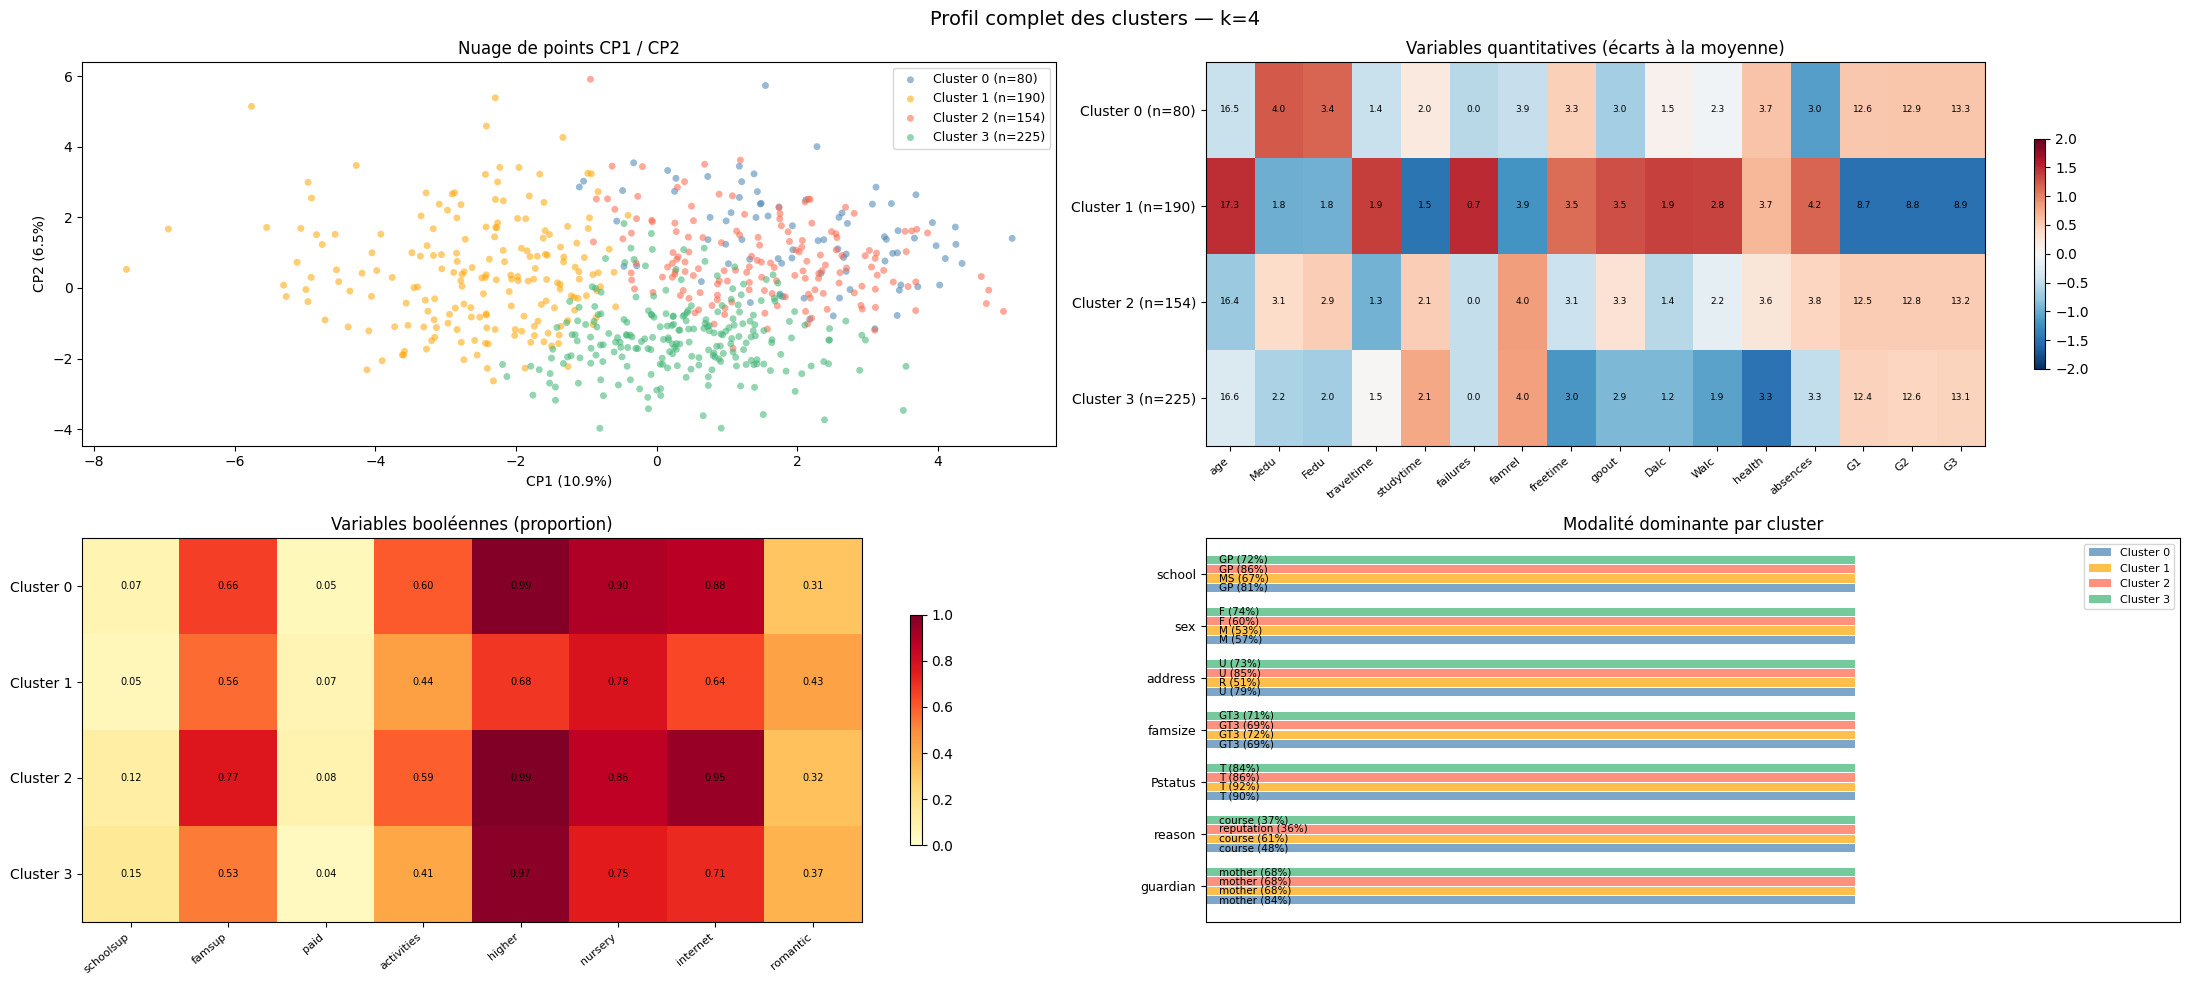

In [36]:
# ---- K-means k=4 — student-por ----
labels_por_4 = KMeans(n_clusters=4, n_init=50, random_state=42).fit_predict(X_por_red)
plot_profil_complet(df_por, labels_por_4, 4, bool_cols, cat_cols, num_cols,
                    raw_df=student_por, X_pca2=X_pca2_por, pca2_obj=pca2_por)


### Analyse K=4

Le passage à k=4 fait éclater l'**Excellent en Famille** (Cluster 2 du k=3, n=197) en deux sous-groupes distincts, tandis que les deux autres clusters restent quasi-intacts.

---

#### Cluster 1 (n=190) — **Décrochage** (inchangé depuis k=3) (202->190)
Provient à 95% de l'ancien Cluster 0 (Décrochage). Le profil est identique et se dessine encore plus nettement :
- Medu=1.83, Fedu=1.78 — **les parents les moins éduqués de tous les clusters**
- failures=0.67, studytime=1.55 (le plus faible), G3=8.88 (les pires résultats)
- goout=3.54, Walc=2.85, Dalc=1.91 — le plus festif
- `higher`=0.68 — seul groupe sous les 70%
- `internet`=0.64 — accès internet le plus faible
- `romantic`=0.43 — le plus romantique
- Sex équilibré (53% H / 47% F)

---

#### Cluster 3 (n=225) — **Hustlers** (inchangé depuis k=3) (250->225)
Provient à 86% de l'ancien Cluster 1. Profil stable :
- Notes correctes G3≈13, aucun échec
- `schoolsup`=0.15 — **le plus dépendant du soutien scolaire externe**
- `famsup`=0.53 et `internet`=0.71 — les plus faibles de ce groupe de bons élèves
- **74% de femmes** — cluster très féminin
- Medu/Fedu modestes (2.16/1.98) : la réussite vient du travail, pas du capital familial

---

L'**Excellent en Famille** (k=3 Cluster 2) se divise en deux selon la **source de l'excellence** :

#### Cluster 0 (n=80) — **Élite par héritage**
Provient de l'ancien Cluster 2. Se distingue par le **plus haut niveau d'éducation parentale** :
- Medu=**3.95**, Fedu=3.38 — quasi-maximum
- G3=13.32, failures≈0, absences=3.02 (les plus faibles)
- `paid`=**0.05** — quasiment pas de cours payants (ils n'en ont pas besoin)
- `activities`=0.60, `higher`=0.99
- Légèrement masculin (57% H)
- Ce groupe réussit grâce à l'environnement familial éduqué, pas au soutien institutionnel

#### Cluster 2 (n=154) — **Excellence par le soutien actif**
Provient aussi de l'ancien Cluster 2, mais se distingue par :
- `famsup`=**0.77** — **le soutien familial le plus élevé de tous les clusters (contre 0.66 avec C0)**
- `internet`=**0.95** — le meilleur accès internet
- Medu=3.12, Fedu=2.87 — éducation parentale bonne mais inférieure au Cluster 0
- G3=13.21, très proches du Cluster 0
- **60% de femmes**
- Ce groupe compense un capital parental légèrement moindre par un soutien actif (famille présente, accès aux ressources numériques)

---

#### Synthèse
La nouveauté de k=4 sur le dataset portugais est la même que sur student-mat : **le groupe d'excellence se scinde selon la *source* de la réussite** — capital éducatif héréditaire (Cluster 0, parents très éduqués, majorité masculine) vs soutien familial et numérique actif (Cluster 2, famsup et internet élevés, majorité féminine). Les deux aboutissent aux mêmes notes mais par des chemins différents.


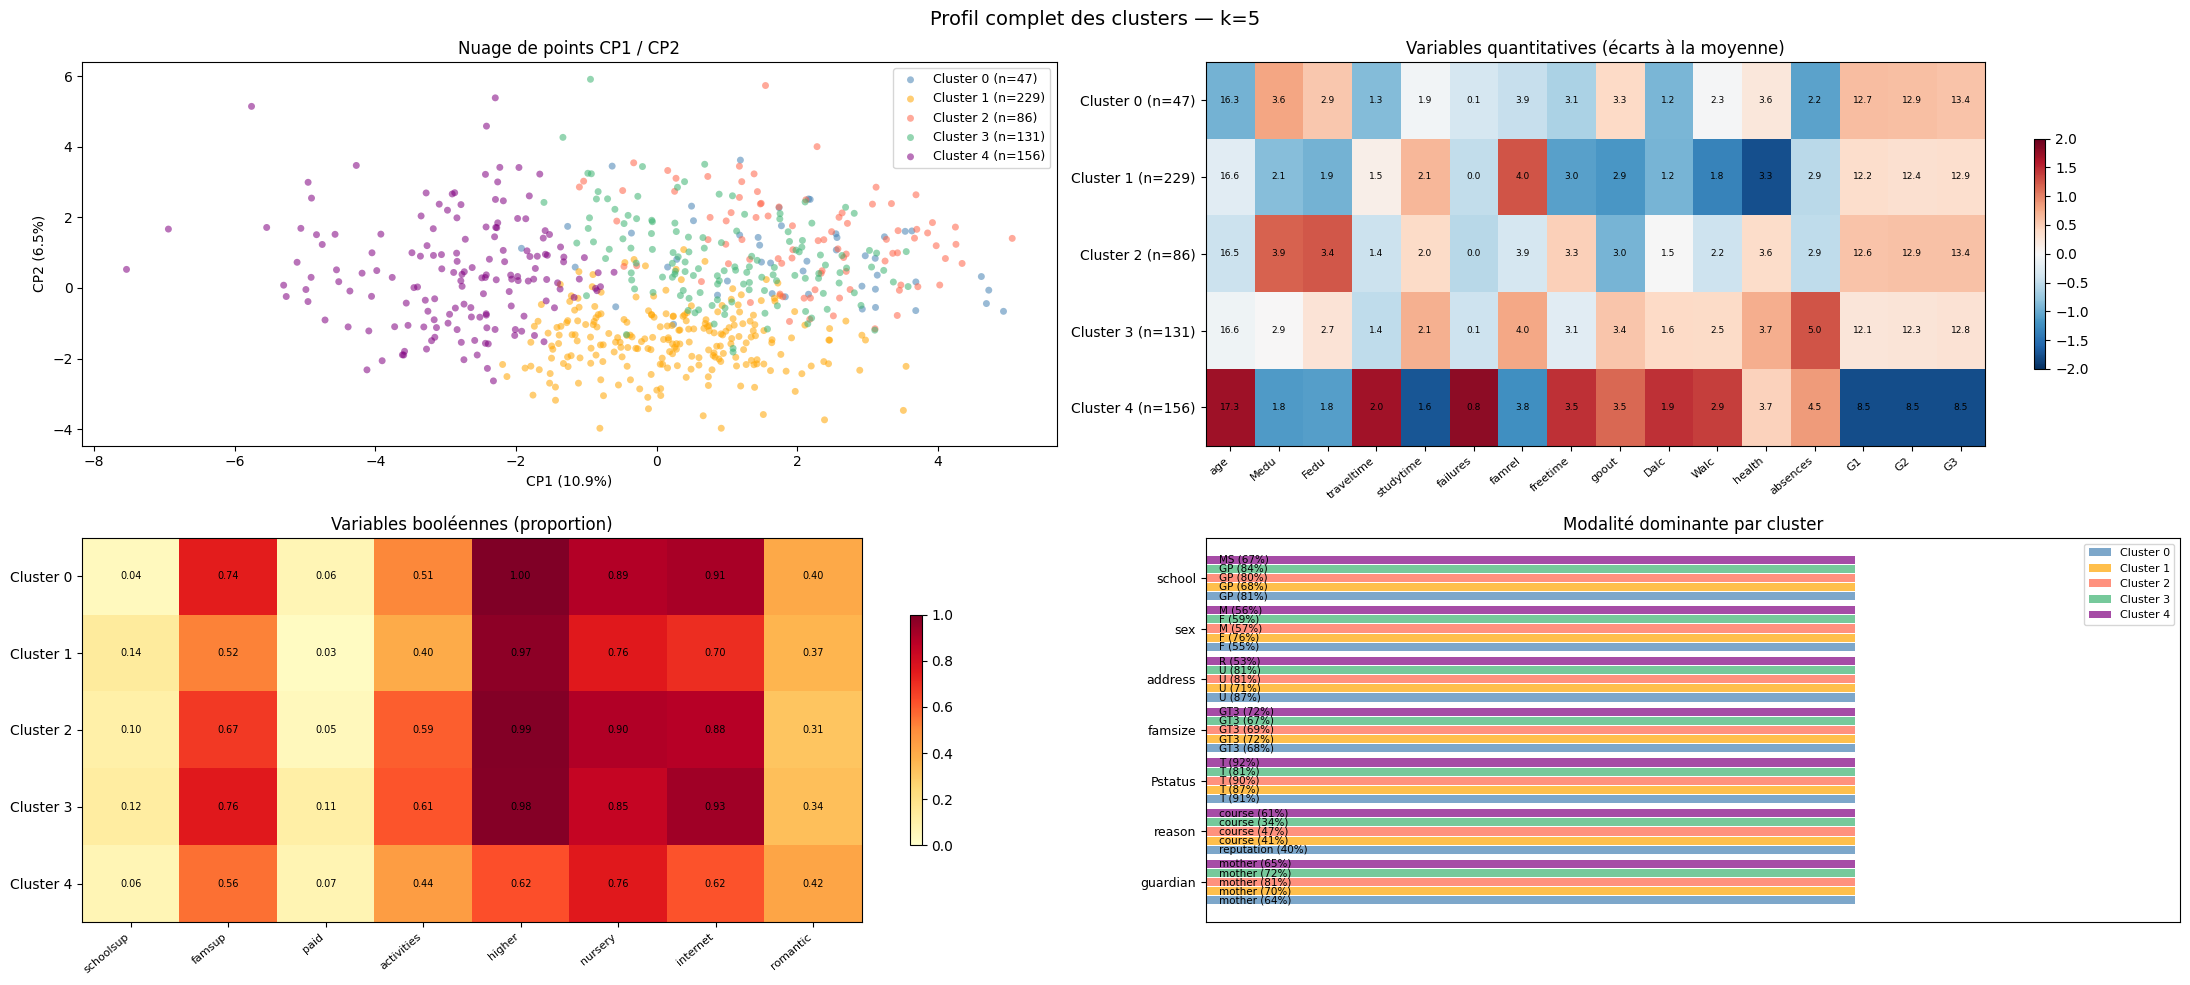

In [37]:
# ---- K-means k=5 — student-por ----
labels_por_5 = KMeans(n_clusters=5, n_init=50, random_state=42).fit_predict(X_por_red)
plot_profil_complet(df_por, labels_por_5, 5, bool_cols, cat_cols, num_cols,
                    raw_df=student_por, X_pca2=X_pca2_por, pca2_obj=pca2_por)


### Analyse K=5

Le passage à k=5 consolide et affine les groupes de k=4. Le mouvement principal est la **subdivision de l'Excellence par soutien** (k=4 Cluster 2) en deux sous-groupes, tandis que les trois autres clusters restent quasi-intacts.

---

#### Cluster 4 (n=156) — **Décrochage** (stable depuis k=3)
Provient à 99% du Cluster 1 du k=4. Le profil est maintenant le plus pur et le plus extrême de toute l'analyse :
- Medu=1.79, Fedu=1.78 — toujours les parents les moins éduqués
- failures=0.79, studytime=1.55, G3=**8.50** (les pires résultats)
- goout=3.51, Walc=2.86 — le plus festif
- `higher`=**0.62** — seul groupe en dessous de 70%
- `internet`=**0.62** — accès internet le plus faible
- `romantic`=0.42 — le plus romantique
- Sex : 56% H / 44% F

---

#### Cluster 1 (n=229) — **Hustlers** (stable depuis k=3)
Provient à 91% du Cluster 3 du k=4. Le groupe le plus grand, le plus stable et le plus homogène :
- G3≈12.88, failures≈0, studytime=2.07
- Medu=2.06, Fedu=1.88 — capital parental modeste, mais compensé par le travail
- `schoolsup`=**0.14** — le plus dépendant du soutien scolaire institutionnel
- `famsup`=0.52 et `internet`=0.70 — parmi les plus faibles des bons élèves
- **76% de femmes** — le cluster le plus féminin de toute l'analyse
- La réussite ici est entièrement auto-portée : ni héritage éducatif, ni soutien familial fort

---

#### Cluster 2 (n=86) — **Élite par héritage** (stable depuis k=4)
Provient à 92% du Cluster 0 du k=4. Le profil ne change quasiment pas :
- Medu=**3.93**, Fedu=3.41 — les parents les plus éduqués
- G3=**13.38** — les meilleures notes
- absences=2.91 — les moins absents
- `paid`=0.05 — quasiment aucun cours payant
- `activities`=0.59, `higher`=0.99
- 57% H / 43% F

---

La vraie nouveauté de k=5 est la **fragmentation de l'Excellence par soutien** (k=4 Cluster 2, n=154) :

#### Cluster 0 (n=47) — **Soutien familial avec capital parental** 
Provient à 87% du Cluster 2 du k=4. Petit groupe très spécifique :
- Medu=3.57, Fedu=2.91 — niveau parental élevé (entre Cluster 2 et Cluster 3)
- G3=13.36, absences=2.23 — très bon profil académique
- `famsup`=0.74, `internet`=0.91 — soutien familial fort ET bon accès internet
- `romantic`=**0.40** — le plus romantique parmi les bons élèves (à noter)
- 55% F / 45% H
- ⚠️ Groupe très petit (n=47) — à interpréter avec prudence

#### Cluster 3 (n=131) — **Excellence par soutien pur**
Provient à 82% du Cluster 2 du k=4. C'est le cœur de l'ancien groupe "Excellence par soutien" :
- Medu=2.85, Fedu=2.73 — capital parental modéré
- G3=12.77
- `famsup`=**0.76** — **le soutien familial le plus élevé de tous les clusters**
- `internet`=**0.93** — le meilleur accès internet
- `activities`=0.61 — fort taux de participation aux activités
- 59% F / 41% H
- Ce groupe compense un capital parental moindre par un environnement de soutien maximal

---

#### Synthèse de la redistribution k=4 → k=5

| k=4 Cluster | Devient k=5 | Mouvement |
|---|---|---|
| Élite par héritage (n=80) | Cluster 2 (n=86) | Stable à 99% |
| Décrochage (n=190) | Cluster 4 (n=156) | Stable à 82%, quelques vers Cluster 1 |
| Excellence soutien (n=154) | Cluster 0 (n=47) + Cluster 3 (n=131) | Se fragmente |
| Hustlers (n=225) | Cluster 1 (n=229) | Stable à 93% |

Le k=5 apporte peu de nouveauté conceptuelle par rapport au k=4 — il confirme et consolide les groupes existants plutôt que d'en révéler de nouveaux. La fragmentation de l'Excellence par soutien est réelle mais le Cluster 0 (n=47) reste trop petit pour tirer des conclusions solides.


ValueError: Length of values (395) does not match length of index (649)

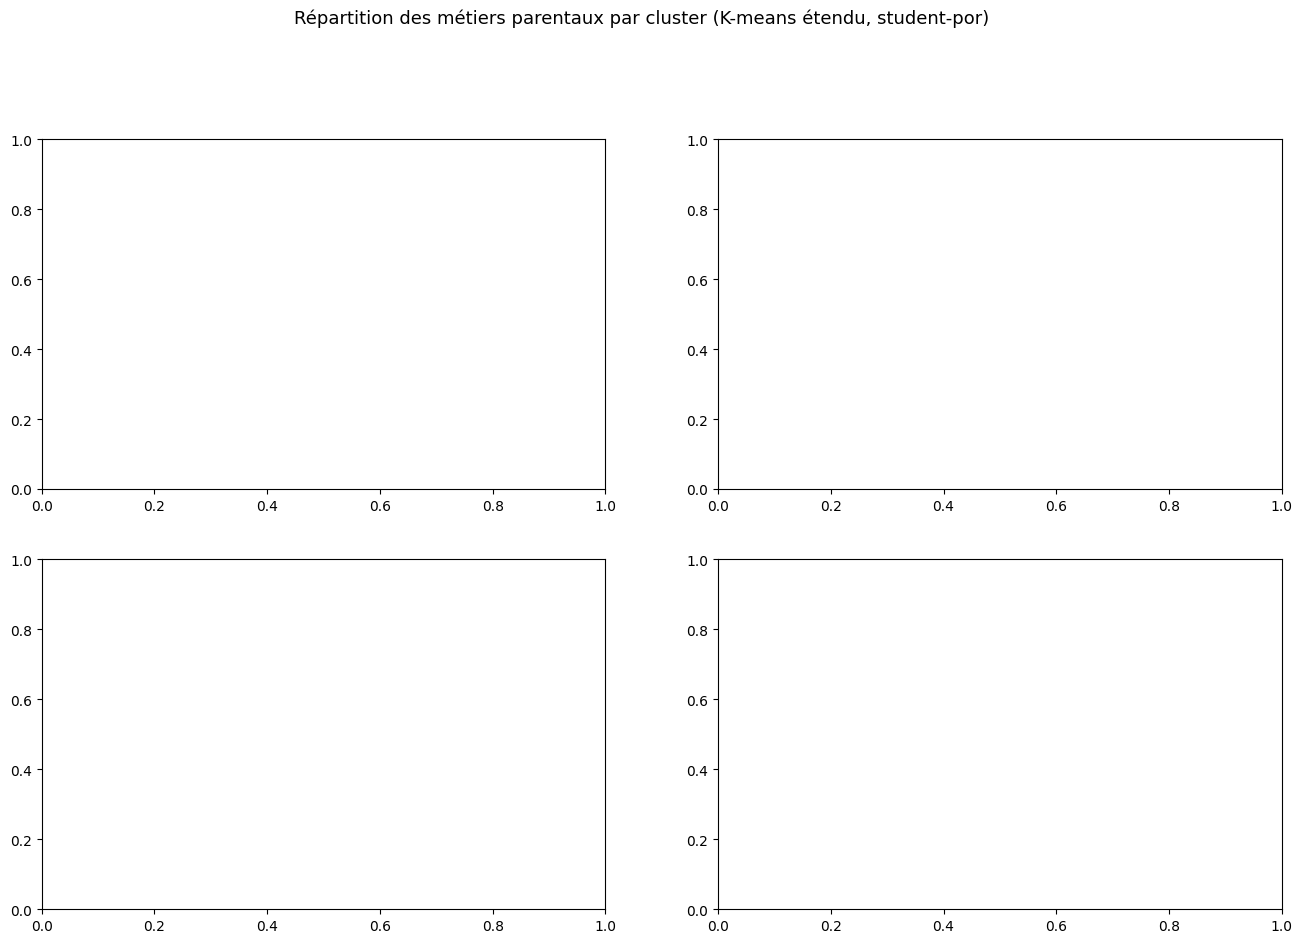

In [38]:
# Répartition Mjob / Fjob par cluster du K-means étendu

job_cats = ['at_home', 'health', 'other', 'services', 'teacher']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Répartition des métiers parentaux par cluster (K-means étendu, student-por)',
    fontsize=13, y=1.01
)

for row_idx, (k, labels) in enumerate([(3, labels_full3), (4, labels_full4)]):
    df_m = student_por.copy()
    df_m['cluster'] = labels

    for col_idx, (job_col, title) in enumerate([('Mjob', 'Métier de la mère'), ('Fjob', 'Métier du père')]):
        ax = axes[row_idx, col_idx]

        ct = pd.crosstab(df_m['cluster'], df_m[job_col]).reindex(columns=job_cats, fill_value=0)
        pct = ct.div(ct.sum(axis=1), axis=0) * 100

        # Population reference row
        pop = student_mat[job_col].value_counts(normalize=True).reindex(job_cats, fill_value=0) * 100
        pct_with_pop = pd.concat([pct, pop.rename('Pop.').to_frame().T])

        n_rows = pct_with_pop.shape[0]
        im = ax.imshow(pct_with_pop.values, cmap='Blues', aspect='auto', vmin=0, vmax=100)

        ax.set_xticks(range(len(job_cats)))
        ax.set_xticklabels(job_cats, rotation=30, ha='right', fontsize=10)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(
            [f'Cluster {i}' for i in range(k)] + ['Pop.'],
            fontsize=10
        )
        ax.set_title(f'k={k} — {title}', fontsize=11)

        for i in range(n_rows):
            for j in range(len(job_cats)):
                val = pct_with_pop.values[i, j]
                color = 'white' if val > 55 else 'black'
                ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')

        # Separator line before pop row
        ax.axhline(k - 0.5, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
        plt.colorbar(im, ax=ax, label='% dans la ligne')

plt.tight_layout()
plt.show()


---
# Conclusions générales — Comparaison student-mat vs student-por

## 1. Robustesse des profils : les mêmes archétypes dans les deux datasets

La principale conclusion de cette analyse est que **les 4 profils d'élèves identifiés par K-means à k=4 se retrouvent dans les deux matières**, mathématiques et portugais, avec des caractéristiques quasi-identiques. Ces groupes ne sont donc pas liés à une matière spécifique mais reflètent des **modes de vie et des contextes sociaux stables**.

| Archétype | MAT | POR | Traits communs |
|---|---|---|---|
| **Décrochage** | C1 (n=69) | C1 (n=190) | Vieux, peu éduqués, festifs, `higher`<75% |
| **Élite héréditaire** | C3 (n=145) | C0 (n=80) | Medu≈4, top grades, peu de soutien externe |
| **Excellence par soutien** | C2 (n=148) | C2 (n=154) | famsup élevé, internet élevé, majorité féminine |
| **Hustlers** | C2 (n=148) | C3 (n=225) | Capital modeste, réussit par travail, très féminin |

---

## 2. Deux voies vers la réussite académique

L'analyse révèle deux chemins distincts et indépendants qui mènent aux bonnes notes :

**Voie 1 — Le capital héréditaire** : Les élèves dont les parents ont un niveau d'éducation très élevé (Medu≈4) réussissent sans avoir besoin de cours payants, de soutien scolaire externe ou de famsup fort. Leurs notes sont les meilleures. Ce groupe est en **majorité masculin** dans les deux datasets.

**Voie 2 — Le soutien actif** : Des élèves avec un capital parental moindre compensent par un environnement de soutien fort — famille présente (famsup élevé) et accès aux ressources numériques (internet élevé). Ils atteignent des résultats proches de la voie 1. Ce groupe est en **majorité féminin**.

---

## 3. La dimension genre est structurante

Le genre n'est pas distribué aléatoirement entre les clusters — il est fortement corrélé aux stratégies de réussite :

- **Les hommes** : surreprésentés dans le décrochage festif (MAT : 72% H) et l'élite héréditaire (POR : 58% H)
- **Les femmes** : surreprésentées dans les Hustlers (MAT : 71% F, POR : 74% F) et l'Excellence par soutien (POR : 60% F)

**Interprétation** : Les femmes réussissent davantage via des stratégies de compensation (travail personnel, mobilisation du soutien familial). Les hommes bénéficient plus directement du capital familial ou décrochent plus facilement en l'absence de celui-ci.

---

## 4. Internet comme proxy socioéconomique

L'accès à internet discrimine très fortement les clusters dans les deux datasets :

| Cluster | MAT internet | POR internet |
|---|---|---|
| Décrochage | 84% | 64% |
| Hustlers | 73% | 71% |
| Excellence soutien | 73% | 95% |
| Élite héréditaire | 95% | 88% |

L'accès à internet n'est pas seulement un outil d'apprentissage — c'est un **indicateur du niveau socioéconomique** de la famille. Le groupe de décrochage portugais n'a que 64% d'accès, soit 30 points de moins que les meilleurs clusters.

---

## 5. Le décrochage est identique dans les deux matières

Le profil décrocheur est **parfaitement stable** entre math et portugais : vieux, peu de capital familial, festif, romantique, peu ambitieux pour le supérieur. Ce n'est pas un problème lié à une matière difficile mais un **mode de vie qui précède et dépasse la scolarité**.

À noter : les décrocheurs portugais ont de meilleures notes (G3≈8.9) que les décrocheurs en maths (G3≈6.1) — le portugais est probablement plus facile ou moins discriminant que les mathématiques.

---

## 6. L'ambition (`higher`) comme signal d'alerte précoce

Dans tous les clusters des deux datasets, `higher` > 94%... sauf dans le cluster de décrochage où il tombe à **68-74%**. C'est le seul indicateur booléen qui distingue vraiment le décrochage des autres groupes. Un élève qui n'aspire pas au supérieur est quasi-systématiquement dans le groupe à risque.
